# RANDOM FOREST

__INDEX__
1. [Understanding Random Forest](#understanding)
2. [Setup and Data Preparation](#setup)
3. [Model Selection Experiments (Random Search and 8-Fold CV)](#expruns)

    3.1. [Full Feature Set (no Feature Engineering and no Feature Selection)](#allfeat)

    3.2. [Feature Ablation: Excluding `previousOwners`](#noprevown)

    3.3. [Feature Engineering Ablations and Additions](#feateng)

4. [Final Model: Selected Configuration and Submission File](#finalconfig)

## 1. Understanding the Random Forest Model <a id="understanding"></a>

<div style="text-align: justify; max-width: 1300px; margin: 1 auto;">

- The Random Forest model (in particular the scikit-learn implementation) works as an ensemble estimator that can train multiple decision trees on different samples of the training data (depending on the parameter configuration) and aggregates their predictions (by averaging the value predicted by each tree) to improve generalization, thus being better at preventing overfitting that happens very often with single decision trees.
- In order to obtain the most diverse ensemble, randomness is introduced by bootstrapping the train set (bagging), so that each tree is fit on different (resampled) data and, additionally, by considering a random set of features when searching for the best split at each node. 
- Bootstrap sampling (bagging): each tree is trained on a bootstrap sample (i.e., samples with replacement), making each tree less similar to each other. In scikit-learn, this is activated by `bootstrap=True` by default and the sample sizes are defined by `max_samples` (although we did not experiment with this parameter in this project). When the bootstrap parameter is set to False, then the whole dataset is used to build each tree. 
- Considering a subset of features when choosing a split: consists in, instead of considering all of the remaining features, the model will only consider a random subset of features and then choose the best split in that subset. In scikit-learn, this is achieved by the configuration of `max_features`.
- This improves the model's capability of generalizing, because it is making its decision based on trees that are more different between them. 
- The parameters explored for model optimisation (during the random search) in our project, besides `bootstrap` and `max_features` were the following:
    - `n_estimators`: number of trees ensembled;
    - `max_depth`: the maximum depth allowed for a tree to reach;
    - `min_samples_split`: the minimum amount of samples to split a node;
    - `min_samples_leaf`: the minimum amount of samples demanded by leaf. A split will only occur if there are at least min_samples_leaf in each child node. 
- In addition, scikit-learn documentation advises on being careful with the parameters that control the size of trees, since unpruned or very deep trees can be too large for some datasets and have unnecessary time and memory consumption. 

</div>

## 2. Setup and Data Preparation  <a id="setup"></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error
import os
from sklearn.feature_selection import SelectFromModel
import random
import logging
from IPython.display import display
import sys

In [ ]:
%run 05_0.1_visualization_helpers.ipynb  

In [ ]:
# All of our preprocessing helper functions are in this notebook
%run 05_0_preproc_helpers.ipynb  

# this is the target column - the value we want to predict 
TARGET_COL = "price"  

# separate features and target variable from the full training datase
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# lists previously defined in 05_0_preproc_helpers.ipynb
categorical_features = ['Brand', 'model', 'transmission', 'fuelType']              
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


In [ ]:
# set configuration for cross validation
N_SPLITS = 8 # number of folds used in k-fold cross validation
RANDOM_STATE = 42

In [ ]:
def _normalize_cats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize categorical strings 
    fill_unknown + column_string_transformer 
    """
    df = df.copy()
    for col in cols_to_normalize:
        if col in df.columns:
            df[col] = fill_unknown(df[col])
            df = column_string_transformer(df, column=col, remove_middle_spaces=True, allow_extra_chars="")
    return df

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def bias(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) - np.asarray(y_pred)))

## 3. Model Selection Experiments (Random Search and 8-Fold CV)  <a id="expruns"></a>

### 3.1. Full Feature Set Experiments<a id="allfeat"></a>

- In this section, we performed a random search to check whether the chosen hyperparameters search space was reasonable and to establish baseline results for the later improvements. We are using all original features (excluding `paintQuality` and `hasDamage` features)

In [ ]:
# creation of the KFold object that will generate the train/validation splits
kf = KFold(
    n_splits=N_SPLITS, # number of folds, in this case will be 8 folds
    shuffle=True,  # shuffle data before splitting to make folds more balanced
    random_state=RANDOM_STATE # using the fixed seed 
)


# Definition of the hyperparameters that will be tested in the Randomized Search
param_distributions = {
    # number of trees in the forest: 
    "n_estimators": [200, 400, 600, 800, 1000], 
    # maximum depth of each tree:
    "max_depth": [5, 7, 9, 11, 15, 20],
    # minimum number of samples required to split an internal node:
    "min_samples_split": [2, 4, 6, 10],
    # minimum number of samples required to be at a leaf node:
    "min_samples_leaf": [1, 2, 4, 8],
    # number of features to consider when looking for the best split:
    "max_features": [None], # using all features
    "bootstrap": [True, False], # whether bootstrap samples are used when building trees
}

N_RANDOM_CONFIGS = 20 # number of random different hyperparameter configurations to try


# this sampler will generate random combinations of hyperparameters
# from the previously defined search space 
sampler = ParameterSampler(
    param_distributions, # the dictionary with the hyperparameter search space
    n_iter=N_RANDOM_CONFIGS, # number of different random configurations to generate
    random_state=RANDOM_STATE 
)

search_results = [] # list that will store summary results for each hyperparameter configuration

# best configuration according to validation rmse
best_rmse = np.inf # our initial best rmse is infinite so any real rmse will be smaller
best_config = None # will store the params corresponding to the best rmse

# best configuration according to validation mae
best_mae = np.inf
best_config_mae = None

# best configuration according to a combined metric 0.5 * rmse + 0.5 * mae on validation
best_combo = np.inf
best_config_combo = None

# we have a log file to store detailed logs of the random search process
# this is useful for later analysis of the results, to avoid losing information if the notebook crashes
# and following the progress of the search
log_path = "rf_random_search_log_.txt"

# opens the log file for writing
with open(log_path, "w", encoding="utf-8") as log_file:

    # this is a helper function to write messages to both console and log file
    def log(msg: str):
        print(msg) # so progress is seen during execution
        log_file.write(msg + "\n") # also write the same message to the log file
        log_file.flush() # flush so log is updated immediately 

    log("# starting random forest")
    log(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS}")
    log(f"param_distributions = {param_distributions}")

    
    # --> main loop of the random search with cross validation
    # each iteration uses one sampled hyperparameter configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f" - CONFIG {config_id}/{N_RANDOM_CONFIGS} ")
        log(f"Parameters: {params}")

        # lists to store validation metrics per fold for this configuration
        fold_rmses = []
        fold_maes  = []
        fold_r2s   = []

        # lists to store training metrics per fold for this configuration
        fold_rmses_train = []
        fold_maes_train  = []
        fold_r2s_train   = []

        # cross validation loop for the current hyperparameter configuration
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            log("")
            log(f"[CONFIG {config_id}] -- FOLD {fold}/{N_SPLITS}")

            
            # - split the data into train and validation for the current fold
            X_train = X.iloc[train_idx].copy() # training features for the current fold
            X_val   = X.iloc[val_idx].copy() # validation features for the current fold
            y_train = y.iloc[train_idx].copy() # training targets for the current fold
            y_val   = y.iloc[val_idx].copy() # validation targets for the current fold

            log(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # log missing values before imputations
            # --> for the numeric features
            log(f"[C{config_id}|F{fold}] NaNs before (just numerical):")
            log(str(X_train[numeric_features].isna().sum()))
            # --> for the categorical features (we are not supposed to have NaNs here because they were already temporarily handled as UNKNOWN, but just in case)
            log(f"[C{config_id}|F{fold}] NaNs before (categorical):")
            log(str(X_train[categorical_features].isna().sum()))
            # count how many "UNKNOWN" exist in the categorical features before further processing
            unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' before (categorical):")
            log(str(unknown_counts_before))

           
            
            # --> Preprocessing
            #    using fit on train and transform on val
            #    each "state" object stores statistics or rules learned from train
            
            # - numerical preprocessing:
            # 1) YEAR 
            # impute year based on median year per model learned from training data
            year_state = fit_year_median(
                X_train,
                year_col="year",
                model_col="model"
            )
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            # 2) MILEAGE
            # impute mileage using a custom imputer that can also enforce absolute values
            mileage_state = fit_mileage_imputer(
                X_train,
                mileage_col="mileage",
                do_abs=True
            )
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            # 3) ENGINE SIZE
            # impute engine size using a imputer fitted on the training data
            engine_state = fit_engine_size_imputer(
                X_train,
                engine_col="engineSize"
            )
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # 4) MPG
            mpg_state = fit_mpg_imputer(
                X_train,
                mpg_col="mpg",
                do_abs=True
            )
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)
            
            # 5) PREVIOUS OWNERS
            owners_state = fit_previous_owners_imputer(
                X_train,
                owners_col="previousOwners",
                year_col="year",
                mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)
            
            # 6) BRAND 
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train,
                valid_brands=valid_brands,
                brand_col="Brand",
                model_col="model",
                year_col="year",
            )
            X_train, brand_corr_train, brand_still_invalid_train = transform_ambiguous_brands(
                X_train,
                brand_state,
            )
            X_val, brand_corr_val, brand_still_invalid_val = transform_ambiguous_brands(
                X_val,
                brand_state,
            )
            
            # 7) MODEL
            model_state = fit_invalid_model_resolver(
                train_df=X_train,
                valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand",
                model_col="model",
                year_col="year",
                fuel_col="fuelType",
                mpg_col="mpg",
            )
            X_train, model_corr_train, model_still_invalid_train = transform_invalid_models(
                X_train,
                model_state,
            )
            X_val, model_corr_val, model_still_invalid_val = transform_invalid_models(
                X_val,
                model_state,
            )
             
            # 8) TRANSMISSION
            transm_state = fit_transmission_resolver(
                train_df=X_train,
                valid_transmissions=valid_transmissions,
                transm_col="transmission",
                brand_col="Brand",
                model_col="model",
                fuel_col="fuelType",
            )
            X_train, transm_corr_train, transm_still_invalid_train = transform_transmission_resolver(
                X_train,
                transm_state,
            )
            X_val, transm_corr_val, transm_still_invalid_val = transform_transmission_resolver(
                X_val,
                transm_state,
            )
            
            # 9) FUEL TYPE
            fuel_state = fit_fueltype_resolver(
                train_df=X_train,
                valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType",
                brand_col="Brand",
                model_col="model",
                transm_col="transmission",
            )
            X_train, fuel_corr_train, fuel_still_invalid_train = transform_fueltype_resolver(
                X_train,
                fuel_state,
            )
            X_val, fuel_corr_val, fuel_still_invalid_val = transform_fueltype_resolver(
                X_val,
                fuel_state,
            )

            # 10) Tax
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize") 


            # --
            log(f"[C{config_id}|F{fold}] Após resolver fuelType:")
            log("  Valores distintos (train): " +
                str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))
            log("  Ainda problemáticos (train): " + str(fuel_still_invalid_train[:10]))
            # --

            
            # Some extra logs for checking if the preprocessing went well
            log(f"[C{config_id}|F{fold}] --- Summary ---")
            num_means_train = X_train[numeric_features].mean()
            num_nans_train  = X_train[numeric_features].isna().sum()
            log("  numerical means (train):")
            log(str(num_means_train))
            log("  numerical NaNs  (train):")
            log(str(num_nans_train))

            num_means_val = X_val[numeric_features].mean()
            num_nans_val  = X_val[numeric_features].isna().sum()
            log("  numerical means  (val):")
            log(str(num_means_val))
            log("  numerical NaNs   (val):")
            log(str(num_nans_val))

            log(f"[C{config_id}|F{fold}] --- categorical summary ---")
            cat_nans_train     = X_train[categorical_features].isna().sum()
            cat_unknown_train  = (X_train[categorical_features] == "UNKNOWN").sum()
            log("  NaNs per categorical (train):")
            log(str(cat_nans_train))
            log("  'UNKNOWN' per categorical  (train):")
            log(str(cat_unknown_train))

            log(f"[C{config_id}|F{fold}] distinct values in categorical (train):")
            for col in categorical_features:
                uniques = sorted(X_train[col].dropna().astype(str).unique())
                if len(uniques) > 30:
                    shown = uniques[:30]
                    log(f"    {col}: {len(uniques)} distinct values. First 30: {shown} ...")
                else:
                    log(f"    {col}: {len(uniques)} distinct values: {uniques}")

            # left UNKNOWN 
            unknown_mask_train = (X_train[categorical_features] == "UNKNOWN")
            unknown_mask_val   = (X_val[categorical_features]   == "UNKNOWN")

            unknown_counts_train = unknown_mask_train.sum()
            unknown_counts_val   = unknown_mask_val.sum()

            rows_with_unknown_train = unknown_mask_train.any(axis=1).sum()
            rows_with_unknown_val   = unknown_mask_val.any(axis=1).sum()

            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after (categorical, train):")
            log(str(unknown_counts_train))
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after  (categorical, val):")
            log(str(unknown_counts_val))
            log(f"[C{config_id}|F{fold}] Num of rows with >=1 UNKNOWN (train): {rows_with_unknown_train}")
            log(f"[C{config_id}|F{fold}] Num of rows with >=1 UNKNOWN (val)  : {rows_with_unknown_val}")


            # categorical encoding
            # (Target encoding for Brand+model, One-Hot for the rest)
            high_card_features = ["Brand", "model"]  # features with high cardinality => treatment with target encoding
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            # --
            log(f"[C{config_id}|F{fold}] high_card_features = {high_card_features}")
            log(f"[C{config_id}|F{fold}] low_card_features  = {low_card_features}")
            # --

            # - Target Encoding para Brand e model
            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)

            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            # One-Hot Encoding for the other categorical features
            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])

            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            log(f"[C{config_id}|F{fold}] X_train_cat shape: {X_train_cat.shape}")
            log(f"[C{config_id}|F{fold}] X_val_cat   shape: {X_val_cat.shape}")


            unknown_cols_train = [col for col in X_train_cat.columns if "UNKNOWN" in str(col)]
            unknown_cols_val   = [col for col in X_val_cat.columns if "UNKNOWN" in str(col)]


            # NUMERICAL SCALING
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features]) # fit on train and transform train
            X_val_num   = scaler.transform(X_val[numeric_features]) # transform validation using same scaler

            # convert numpy arrays back to dataframes with meaningful column names and consistent indices
            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features]
            )

            log(f"[C{config_id}|F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
            log(f"[C{config_id}|F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

            # concatenate scaled numeric and encoded categorical features
            X_train_final = pd.concat(
                [X_train_num_df, X_train_cat],
                axis=1
            )
            X_val_final = pd.concat(
                [X_val_num_df, X_val_cat],
                axis=1
            )

            log(f"[C{config_id}|F{fold}] X_train_final shape: {X_train_final.shape}")
            log(f"[C{config_id}|F{fold}] X_val_final   shape: {X_val_final.shape}")

            
            # instantiate and train the random forest regressor for this configuration
            rf = RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1, # uses all available cores 
                **params # current hyperparameter configuration
            )

            log(f"[C{config_id}|F{fold}] training RandomForestRegressor...")
            rf.fit(X_train_final, y_train) # train the model on the fully processed training data

            # generate predictions on training and validation sets for metric computation
            y_pred_train = rf.predict(X_train_final)
            y_pred_val   = rf.predict(X_val_final)


            # compute metrics per fold for both train and validation
            # used to monitor performance and detect potential overfitting/underfitting
            # Validation metrics:
            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)

            # TRAIN metrics: 
            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)

            log(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.4f} | MAE: {mae_tr:.4f} | R²: {r2_tr:.4f}")
            log(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.4f} | MAE: {mae_val:.4f} | R²: {r2_val:.4f}")

            # store the validation metrics for this fold
            fold_rmses.append(rmse_val)
            fold_maes.append(mae_val)
            fold_r2s.append(r2_val)

            fold_rmses_train.append(rmse_tr)
            fold_maes_train.append(mae_tr)
            fold_r2s_train.append(r2_tr)

        # average metrics of all folds for this configuration
        mean_rmse_val = np.mean(fold_rmses)
        mean_mae_val  = np.mean(fold_maes)
        mean_r2_val   = np.mean(fold_r2s)

        mean_rmse_tr = np.mean(fold_rmses_train)
        mean_mae_tr  = np.mean(fold_maes_train)
        mean_r2_tr   = np.mean(fold_r2s_train)

        # combined score giving equal weight to rmse and mae on validation
        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log("")
        log(f"Config {config_id} - TRAIN RMSE mean: {mean_rmse_tr:.4f} | MAE: {mean_mae_tr:.4f} | R²: {mean_r2_tr:.4f}")
        log(f"Config {config_id} - VAL   RMSE mean: {mean_rmse_val:.4f} | MAE: {mean_mae_val:.4f} | R²: {mean_r2_val:.4f}")
        log(f"Config {config_id} - Score combined (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.4f}")


        # store a record with configuration, metrics and combined score to the search results list
        search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "combo_score": combo_score,
        })

        # update (or not) RMSE (VAL)
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id} w/ mean RMSE (VAL) = {best_rmse:.4f}")

        # update (or not) MAE (VAL)
        if mean_mae_val < best_mae:
            best_mae = mean_mae_val
            best_config_mae = {**params}
            log(f"[NEW BEST MAE] Config {config_id} w/ mean MAE  (VAL) = {best_mae:.4f}")

        # update (or not) best combined score (VAL)
        if combo_score < best_combo:
            best_combo = combo_score
            best_config_combo = {**params}
            log(f"[NEW BEST COMBINED] Config {config_id} w/ score = {best_combo:.4f}")


    # after iterating over all sampled configurations, log a summary of the best ones
    log("")
    log("")
    log("# =============================")
    log("# END")
    log("# =============================")
    log(f"Best config (min RMSE VAL): {best_config}")
    log(f"best mean RMSE  (VAL): {best_rmse:.4f}")
    log(f"Best config (min MAE VAL): {best_config_mae}")
    log(f"BEST mean MAE (VAL): {best_mae:.4f}")
    log(f"best config (combined score VAL): {best_config_combo}")
    log(f"best combined score (VAL): {best_combo:.4f}")


# final summary of the random search (as a dataframe)
results_df = pd.DataFrame(search_results) # convert list of dicts to dataframe
results_df_sorted = results_df.sort_values(by="rmse_mean", ascending=True) # sort by validation rmse

display(results_df_sorted.head(10)) # configurations with lowest validation rmse

# print the best configurations according to each criterion
print("\nBest config (min RMSE VAL):")
print(best_config)
print("best mean RMSE (VAL):", best_rmse)

print("\nbest config (min MAE VAL):")
print(best_config_mae)
print("best mean MAE  (VAL):", best_mae)

print("\nbest config found (combined score VAL = 0.5*RMSE + 0.5*MAE):")
print(best_config_combo)
print("best combined score (VAL):", best_combo)

print(f"\nLogs stored at: {log_path}")


# starting random forest
N_SPLITS = 8, N_RANDOM_CONFIGS = 20
param_distributions = {'n_estimators': [200, 400, 600, 800, 1000], 'max_depth': [5, 7, 9, 11, 15, 20], 'min_samples_split': [2, 4, 6, 10], 'min_samples_leaf': [1, 2, 4, 8], 'max_features': [None], 'bootstrap': [True, False]}

 - CONFIG 1/20 
Parameters: {'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 15, 'bootstrap': False}

[CONFIG 1] -- FOLD 1/8
[C1|F1] X_train shape: (66476, 10), X_val shape: (9497, 10)
[C1|F1] y_train shape: (66476,), y_val shape: (9497,)
[C1|F1] NaNs before (just numerical):
year              1306
mileage           1252
engineSize        1344
tax               6940
mpg               6961
previousOwners    1331
dtype: int64
[C1|F1] NaNs before (categorical):
Brand           0
model           0
transmission    0
fuelType        0
dtype: int64
[C1|F1] 'UNKNOWN' before (categorical):
Brand           1328
model           1314
transmission    1944
fuelTy

,config_id,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,bootstrap,rmse_train_mean,mae_train_mean,r2_train_mean,rmse_mean,mae_mean,r2_mean,combo_score
7,8,1000,6,1,None,15,True,1560.356118,999.831279,0.974317,2262.761511,1336.104531,0.945830,1799.433021
2,3,200,6,2,None,15,True,1654.235643,1016.679770,0.971132,2302.755387,1340.440144,0.943885,1821.597765
1,2,600,10,8,None,20,True,2071.908363,1152.730895,0.954716,2452.548694,1384.109758,0.936353,1918.329226
17,18,1000,2,8,None,20,True,2072.037323,1152.623896,0.954710,2453.685894,1384.229266,0.936296,1918.957580
5,6,400,2,2,None,11,True,2104.876773,1363.980034,0.953265,2481.456725,1511.768869,0.934906,1996.612797
0,1,400,10,2,None,15,False,1833.286328,1133.884158,0.964532,2688.265474,1541.592787,0.923514,2114.929130
13,14,200,10,8,None,20,False,2111.611735,1195.377448,0.952962,2730.215599,1544.515913,0.920979,2137.365756
9,10,800,10,8,None,15,False,2200.235542,1282.587178,0.948932,2734.513206,1554.392672,0.920733,2144.452939
4,5,800,2,4,None,20,False,1730.254047,977.062641,0.968414,2747.313085,1552.029966,0.920200,2149.671526
6,7,200,10,4,None,9,True,2555.086939,1626.459315,0.931138,2755.067827,1700.358886,0.919803,2227.713357



Best config (min RMSE VAL):
{'n_estimators': 1000, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15, 'bootstrap': True}
best mean RMSE (VAL): 2262.7615106654034

best config (min MAE VAL):
{'n_estimators': 1000, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15, 'bootstrap': True}
best mean MAE  (VAL): 1336.1045313730594

best config found (combined score VAL = 0.5*RMSE + 0.5*MAE):
{'n_estimators': 1000, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15, 'bootstrap': True}
best combined score (VAL): 1799.4330210192315

Logs stored at: rf_random_search_log_.txt


### 3.2. Feature Ablation Experiment: Excluding `previousOwners` and Applying a Log-Transformed Target (price) <a id="noprevown"></a>

In [ ]:
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg']  # we removed previousOwners feature from here
categorical_features = ["Brand", "model", "transmission", "fuelType"]

# copy to avoid problems between folds/configs 
BASE_NUMERIC_FEATURES = numeric_features.copy()

# creation of the KFold object that will generate the train/validation splits
kf = KFold(
    n_splits=N_SPLITS,  # number of folds, in this case will be 8 folds
    shuffle=True,  # shuffle data before splitting to make folds more balanced
    random_state=RANDOM_STATE  # using the fixed seed
)

# Definition of the hyperparameters that will be tested in the Randomized Search
param_distributions = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [7, 9, 11, 15, 20],
    "min_samples_split": [2, 4, 6, 10],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": ["sqrt", 0.33, 0.5, 1.0],
    "bootstrap": [True],
}

N_RANDOM_CONFIGS = 15  # number of random different hyperparameter configurations to try

# this sampler will generate random combinations of hyperparameters
# from the previously defined search space
sampler = ParameterSampler(
    param_distributions,  # the dictionary with the hyperparameter search space
    n_iter=N_RANDOM_CONFIGS,  # number of different random configurations to generate
    random_state=RANDOM_STATE
)

search_results = []  # list that will store summary results for each hyperparameter configuration

# best configuration according to validation rmse
best_rmse = np.inf  # our initial best rmse is infinite so any real first rmse will be smaller
best_config = None  # will store the params corresponding to the best rmse

# best configuration according to validation mae
best_mae = np.inf
best_config_mae = None

# best configuration according to a combined metric 0.5 * rmse + 0.5 * mae on validation
best_combo = np.inf
best_config_combo = None

# we have a log file to store detailed logs of the random search process
log_path = "rf_random_search_log_2_.txt"

# opens the log file for writing
with open(log_path, "w", encoding="utf-8") as log_file:

    # this is a helper function to write messages to both console and log file
    def log(msg: str):
        print(msg)  # so progress is visible during execution
        log_file.write(msg + "\n")  # also write the same message to the log file
        log_file.flush()  # flush so log is updated immediately 

    log("# starting random forest")
    log(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS}")
    log(f"param_distributions = {param_distributions}")
    log("Target transform: log1p(price) during training; metrics computed back in price via expm1(pred).")
    log("Note: previousOwners is not used (excluded from numeric_features and dropped per fold).")

    # --> main loop of the random search with cross validation
    # each iteration uses one sampled hyperparameter configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f" - CONFIG {config_id}/{N_RANDOM_CONFIGS} ")
        log(f"Parameters: {params}")

        # lists to store validation metrics per fold for this configuration
        fold_rmses = []
        fold_maes  = []
        fold_r2s   = []

        # lists to store training metrics per fold for this configuration
        fold_rmses_train = []
        fold_maes_train  = []
        fold_r2s_train   = []

        # cross validation loop for the current hyperparameter configuration
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            log("")
            log(f"[CONFIG {config_id}] -- FOLD {fold}/{N_SPLITS}")

            # local copy of numeric features for this fold.
            # if they need to later be updated with engineer features (ex.: year by age), we update this local list safely
            numeric_features_fold = BASE_NUMERIC_FEATURES.copy()

            # - split the data into train and validation for the current fold
            X_train = X.iloc[train_idx].copy()  # training features for the current fold
            X_val   = X.iloc[val_idx].copy()    # validation features for the current fold
            y_train = y.iloc[train_idx].copy()  # training targets for the current fold 
            y_val   = y.iloc[val_idx].copy()    # validation targets for the current fold 

            # additional check: dropping previousOwners so it can never leak into the final matrix
            X_train = X_train.drop(columns=["previousOwners"], errors="ignore")
            X_val   = X_val.drop(columns=["previousOwners"], errors="ignore")

            # Log target strategy
            # training on log(1 + price) to reduce skew and stabilize variance
            y_train_log = np.log1p(y_train)
            y_val_log   = np.log1p(y_val)  # probably will be unnecessary

            log(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # log missing values before imputations
            log(f"[C{config_id}|F{fold}] NaNs before (just numerical):")
            log(str(X_train[numeric_features_fold].isna().sum()))
            log(f"[C{config_id}|F{fold}] NaNs before (categorical):")
            log(str(X_train[categorical_features].isna().sum()))
            unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' before (categorical):")
            log(str(unknown_counts_before))


            # --> Preprocessing
            #    using fit on train and transform on val
            #    each "state" object stores statistics or rules learned from train
            
            # - numerical preprocessing:
            # 1) YEAR 
            # impute year based on median year per model learned from training data
            year_state = fit_year_median(
                X_train,
                year_col="year",
                model_col="model"
            )
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            # 2) MILEAGE
            mileage_state = fit_mileage_imputer(
                X_train,
                mileage_col="mileage",
                do_abs=True
            )
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            # 3) ENGINE SIZE
            engine_state = fit_engine_size_imputer(
                X_train,
                engine_col="engineSize"
            )
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # 4) MPG
            mpg_state = fit_mpg_imputer(
                X_train,
                mpg_col="mpg",
                do_abs=True
            )
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            # 5) BRAND
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train,
                valid_brands=valid_brands,
                brand_col="Brand",
                model_col="model",
                year_col="year",
            )
            X_train, brand_corr_train, brand_still_invalid_train = transform_ambiguous_brands(
                X_train,
                brand_state,
            )
            X_val, brand_corr_val, brand_still_invalid_val = transform_ambiguous_brands(
                X_val,
                brand_state,
            )

            # 6) MODEL
            model_state = fit_invalid_model_resolver(
                train_df=X_train,
                valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand",
                model_col="model",
                year_col="year",
                fuel_col="fuelType",
                mpg_col="mpg",
            )
            X_train, model_corr_train, model_still_invalid_train = transform_invalid_models(
                X_train,
                model_state,
            )
            X_val, model_corr_val, model_still_invalid_val = transform_invalid_models(
                X_val,
                model_state,
            )

            # 7) TRANSMISSION
            transm_state = fit_transmission_resolver(
                train_df=X_train,
                valid_transmissions=valid_transmissions,
                transm_col="transmission",
                brand_col="Brand",
                model_col="model",
                fuel_col="fuelType",
            )
            X_train, transm_corr_train, transm_still_invalid_train = transform_transmission_resolver(
                X_train,
                transm_state,
            )
            X_val, transm_corr_val, transm_still_invalid_val = transform_transmission_resolver(
                X_val,
                transm_state,
            )

            # 8) FUEL TYPE
            fuel_state = fit_fueltype_resolver(
                train_df=X_train,
                valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType",
                brand_col="Brand",
                model_col="model",
                transm_col="transmission",
            )
            X_train, fuel_corr_train, fuel_still_invalid_train = transform_fueltype_resolver(
                X_train,
                fuel_state,
            )
            X_val, fuel_corr_val, fuel_still_invalid_val = transform_fueltype_resolver(
                X_val,
                fuel_state,
            )
            log(f"[C{config_id}|F{fold}] Após resolver fuelType:")
            log("  Valores distintos (train): " +
                str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))
            log("  Ainda problemáticos (train): " + str(fuel_still_invalid_train[:10]))

            # 9) TAX
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            # Some extra logs for checking if the preprocessing went well
            log(f"[C{config_id}|F{fold}] --- Summary ---")
            num_means_train = X_train[numeric_features_fold].mean()
            num_nans_train  = X_train[numeric_features_fold].isna().sum()
            log("  numerical means (train):")
            log(str(num_means_train))
            log("  numerical NaNs  (train):")
            log(str(num_nans_train))

            num_means_val = X_val[numeric_features_fold].mean()
            num_nans_val  = X_val[numeric_features_fold].isna().sum()
            log("  numerical means  (val):")
            log(str(num_means_val))
            log("  numerical NaNs   (val):")
            log(str(num_nans_val))

            log(f"[C{config_id}|F{fold}] --- categorical summary ---")
            cat_nans_train     = X_train[categorical_features].isna().sum()
            cat_unknown_train  = (X_train[categorical_features] == "UNKNOWN").sum()
            log("  NaNs per categorical (train):")
            log(str(cat_nans_train))
            log("  'UNKNOWN' per categorical  (train):")
            log(str(cat_unknown_train))

            log(f"[C{config_id}|F{fold}] distinct values in categorical (train):")
            for col in categorical_features:
                uniques = sorted(X_train[col].dropna().astype(str).unique())
                if len(uniques) > 30:
                    shown = uniques[:30]
                    log(f"    {col}: {len(uniques)} distinct values. First 30: {shown} ...")
                else:
                    log(f"    {col}: {len(uniques)} distinct values: {uniques}")


            # left UNKNOWN 
            unknown_mask_train = (X_train[categorical_features] == "UNKNOWN")
            unknown_mask_val   = (X_val[categorical_features]   == "UNKNOWN")
            unknown_counts_train = unknown_mask_train.sum()
            unknown_counts_val   = unknown_mask_val.sum()
            rows_with_unknown_train = unknown_mask_train.any(axis=1).sum()
            rows_with_unknown_val   = unknown_mask_val.any(axis=1).sum()

            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after (categorical, train):")
            log(str(unknown_counts_train))
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after  (categorical, val):")
            log(str(unknown_counts_val))
            log(f"[C{config_id}|F{fold}] Num of rows with >=1 UNKNOWN (train): {rows_with_unknown_train}")
            log(f"[C{config_id}|F{fold}] Num of rows with >=1 UNKNOWN (val)  : {rows_with_unknown_val}")

            # categorical encoding
            # (Target encoding for Brand+model, One-Hot for the rest)
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            log(f"[C{config_id}|F{fold}] high_card_features = {high_card_features}")
            log(f"[C{config_id}|F{fold}] low_card_features  = {low_card_features}")

            # - Target Encoding para Brand e model
            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)

            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            # - One-Hot Encoding for the other categorical features
            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])

            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            log(f"[C{config_id}|F{fold}] X_train_cat shape: {X_train_cat.shape}")
            log(f"[C{config_id}|F{fold}] X_val_cat   shape: {X_val_cat.shape}")

            unknown_cols_train = [col for col in X_train_cat.columns if "UNKNOWN" in str(col)]
            unknown_cols_val   = [col for col in X_val_cat.columns if "UNKNOWN" in str(col)]


            # --> NUMERICAL SCALING
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features_fold])
            X_val_num   = scaler.transform(X_val[numeric_features_fold])

            # convert numpy arrays back to dataframes with meaningful column names and consistent indices
            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features_fold]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features_fold]
            )

            log(f"[C{config_id}|F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
            log(f"[C{config_id}|F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

            # concatenate scaled numeric and encoded categorical features
            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            log(f"[C{config_id}|F{fold}] X_train_final shape: {X_train_final.shape}")
            log(f"[C{config_id}|F{fold}] X_val_final   shape: {X_val_final.shape}")


            # instantiate and train the random forest regressor for this configuration
            rf = RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **params
            )

            log(f"[C{config_id}|F{fold}] training RandomForestRegressor (log-target)...")
            rf.fit(X_train_final, y_train_log)

            # predictions in log  -> transform to original scale (price) for evaluation
            y_pred_train_log = rf.predict(X_train_final)
            y_pred_val_log   = rf.predict(X_val_final)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)


            # compute metrics per fold for both train and validation
            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)

            log(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.4f} | MAE: {mae_tr:.4f} | R²: {r2_tr:.4f}")
            log(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.4f} | MAE: {mae_val:.4f} | R²: {r2_val:.4f}")

            fold_rmses.append(rmse_val)
            fold_maes.append(mae_val)
            fold_r2s.append(r2_val)

            fold_rmses_train.append(rmse_tr)
            fold_maes_train.append(mae_tr)
            fold_r2s_train.append(r2_tr)

        # average metrics of all folds for this configuration
        mean_rmse_val = np.mean(fold_rmses)
        mean_mae_val  = np.mean(fold_maes)
        mean_r2_val   = np.mean(fold_r2s)

        mean_rmse_tr = np.mean(fold_rmses_train)
        mean_mae_tr  = np.mean(fold_maes_train)
        mean_r2_tr   = np.mean(fold_r2s_train)

        # combined score giving equal weight to rmse and mae on validation
        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log("")
        log(f"Config {config_id} - TRAIN RMSE mean: {mean_rmse_tr:.4f} | MAE: {mean_mae_tr:.4f} | R²: {mean_r2_tr:.4f}")
        log(f"Config {config_id} - VAL   RMSE mean: {mean_rmse_val:.4f} | MAE: {mean_mae_val:.4f} | R²: {mean_r2_val:.4f}")
        log(f"Config {config_id} - Score combined (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.4f}")

        search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "combo_score": combo_score,
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id} w/ mean RMSE (VAL) = {best_rmse:.4f}")

        if mean_mae_val < best_mae:
            best_mae = mean_mae_val
            best_config_mae = {**params}
            log(f"[NEW BEST MAE] Config {config_id} w/ mean MAE  (VAL) = {best_mae:.4f}")

        if combo_score < best_combo:
            best_combo = combo_score
            best_config_combo = {**params}
            log(f"[NEW BEST COMBINED] Config {config_id} w/ score = {best_combo:.4f}")

    log("")
    log("")
    log("# =============================")
    log("# END")
    log("# =============================")
    log(f"Best config (min RMSE VAL): {best_config}")
    log(f"best mean RMSE  (VAL): {best_rmse:.4f}")
    log(f"Best config (min MAE VAL): {best_config_mae}")
    log(f"BEST mean MAE (VAL): {best_mae:.4f}")
    log(f"best config (combined score VAL): {best_config_combo}")
    log(f"best combined score (VAL): {best_combo:.4f}")


# final summary of the random search (as a dataframe)
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="rmse_mean", ascending=True)

display(results_df_sorted.head(10))

print("\nBest config (min RMSE VAL):")
print(best_config)
print("best mean RMSE (VAL):", best_rmse)

print("\nbest config (min MAE VAL):")
print(best_config_mae)
print("best mean MAE  (VAL):", best_mae)

print("\nbest config found (combined score VAL = 0.5*RMSE + 0.5*MAE):")
print(best_config_combo)
print("best combined score (VAL):", best_combo)

print(f"\nLogs stored at: {log_path}")


# starting random forest
N_SPLITS = 8, N_RANDOM_CONFIGS = 15
param_distributions = {'n_estimators': [200, 400, 600, 800, 1000], 'max_depth': [7, 9, 11, 15, 20], 'min_samples_split': [2, 4, 6, 10], 'min_samples_leaf': [1, 2, 4, 6, 8], 'max_features': ['sqrt', 0.33, 0.5, 1.0], 'bootstrap': [True]}
Target transform: log1p(price) during training; metrics computed back in euros via expm1(pred).
Note: previousOwners is not used (excluded from numeric_features and dropped per fold).

 - CONFIG 1/15 
Parameters: {'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 11, 'bootstrap': True}

[CONFIG 1] -- FOLD 1/8
[C1|F1] X_train shape: (66476, 9), X_val shape: (9497, 9)
[C1|F1] y_train shape: (66476,), y_val shape: (9497,)
[C1|F1] NaNs before (just numerical):
year          1306
mileage       1252
engineSize    1344
tax           6940
mpg           6961
dtype: int64
[C1|F1] NaNs before (categorical):
Brand           0
model           0
transmissio

,config_id,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,bootstrap,rmse_train_mean,mae_train_mean,r2_train_mean,rmse_mean,mae_mean,r2_mean,combo_score
6,7,1000,2,2,0.33,20,True,1749.613634,966.927495,0.967707,2376.031570,1306.843493,0.940243,1841.437531
1,2,1000,10,4,0.5,15,True,2061.164838,1162.433703,0.955184,2414.308057,1354.123910,0.938320,1884.215984
8,9,800,10,2,sqrt,20,True,2090.574201,1129.708403,0.953897,2535.587984,1366.144897,0.931972,1950.866440
13,14,600,2,8,0.5,15,True,2293.772583,1260.733852,0.944499,2546.586228,1402.361378,0.931411,1974.473803
11,12,800,10,2,sqrt,15,True,2247.398643,1266.204570,0.946722,2606.574134,1433.685997,0.928141,2020.130065
7,8,1000,2,4,0.5,11,True,2403.005051,1423.505121,0.939089,2617.614765,1518.454457,0.927565,2068.034611
0,1,400,4,2,1.0,11,True,2317.639853,1424.902550,0.943340,2619.219163,1553.037194,0.927478,2086.128179
4,5,200,6,2,1.0,11,True,2341.113557,1429.937417,0.942187,2627.828991,1554.615266,0.926999,2091.222128
5,6,200,10,8,0.5,11,True,2533.152801,1458.113861,0.932313,2703.905019,1539.446499,0.922719,2121.675759
3,4,1000,6,8,sqrt,15,True,2699.447436,1442.454293,0.923135,2884.552549,1540.446587,0.912015,2212.499568



Best config (min RMSE VAL):
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True}
best mean RMSE (VAL): 2376.03157003845

best config (min MAE VAL):
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True}
best mean MAE  (VAL): 1306.8434926812392

best config found (combined score VAL = 0.5*RMSE + 0.5*MAE):
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True}
best combined score (VAL): 1841.4375313598446

Logs stored at: rf_random_search_log_2_.txt


### 3.3. Feature Engineering: Ablations and Additions <a id="feateng"></a>

#### 3.3.1. Original and Engineered Features (No Feature Selection) with a Log-Transformed Target (price) <a id="featengnosel"></a>

In [ ]:
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners'] #we are working with previous owners again 

# creation of the KFold object that will generate the train/validation splits
kf = KFold(
    n_splits=N_SPLITS, # number of folds, in this case will be 8 folds
    shuffle=True,  # shuffle data before splitting to make folds more balanced
    random_state=RANDOM_STATE # using the fixed seed 
)

# Definition of the hyperparameters that will be tested in the random search
param_distributions = {
    "n_estimators": [200, 400, 600, 800, 1000], 
    "max_depth": [5, 7, 9, 11, 15, 20],
    "min_samples_split": [2, 4, 6, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None], 
    "bootstrap": [True, False], 
}

N_RANDOM_CONFIGS = 8 # number of random different hyperparameter configurations to try


# this sampler will generate random combinations of hyperparameters
# from the previously defined search space 
sampler = ParameterSampler(
    param_distributions, # the dictionary with the hyperparameter search space
    n_iter=N_RANDOM_CONFIGS, # number of different random configurations to generate
    random_state=RANDOM_STATE 
)

search_results = [] # list that will store summary results for each hyperparameter configuration

# best configuration according to validation rmse
best_rmse = np.inf # our initial best rmse is infinite so any real first rmse will be smaller
best_config = None # will store the params corresponding to the best rmse

# best configuration according to validation mae
best_mae = np.inf
best_config_mae = None

# best configuration according to a combined metric 0.5 * rmse + 0.5 * mae on validation
best_combo = np.inf
best_config_combo = None

# we have a log file to store detailed logs of the random search process
# this is useful for later analysis of the results, to avoid losing information if the notebook crashes
# and following the progress of the search
log_path = "rf_random_search_log__felogpricenofs_1612_.txt"

# opens the log file for writing
with open(log_path, "w", encoding="utf-8") as log_file:

    # this is a helper function to write messages to both console and log file
    def log(msg: str):
        print(msg) # so progress is visible during execution
        log_file.write(msg + "\n") # also write the same message to the log file
        log_file.flush() # flush so log is updated immediately on disk

    log("# starting random forest")
    log(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS}")
    log(f"param_distributions = {param_distributions}")

    # main loop of the random search with cross validation
    # each iteration uses one sampled hyperparameter configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f" - CONFIG {config_id}/{N_RANDOM_CONFIGS} ")
        log(f"Parameters: {params}")

        # lists to store validation metrics per fold for this configuration
        fold_rmses = []
        fold_maes  = []
        fold_r2s   = []

        # lists to store training metrics per fold for this configuration
        fold_rmses_train = []
        fold_maes_train  = []
        fold_r2s_train   = []

        # cross validation loop for the current hyperparameter configuration
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            log("")
            log(f"[CONFIG {config_id}] -- FOLD {fold}/{N_SPLITS}")

            # - split the data into train and validation for the current fold
            X_train = X.iloc[train_idx].copy() # training features for the current fold
            X_val   = X.iloc[val_idx].copy() # validation features for the current fold
            y_train = y.iloc[train_idx].copy() # training targets for the current fold
            y_val   = y.iloc[val_idx].copy() # validation targets for the current fold

            # log target (price) 
            y_train_log = np.log1p(y_train)

            log(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # log missing values BEFORE imputations
            # --> for the numeric features
            log(f"[C{config_id}|F{fold}] NaNs before (just numerical):")
            log(str(X_train[numeric_features].isna().sum()))
            # --> for the categorical features (we are not supposed to have NaNs here because they were already temporarily handled as UNKNOWN, but just in case)
            log(f"[C{config_id}|F{fold}] NaNs before (categorical):")
            log(str(X_train[categorical_features].isna().sum()))
            # count how many "UNKNOWN" exist in the categorical features before further processing
            unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' before (categorical):")
            log(str(unknown_counts_before))


            # --> Preprocessing
            #    using fit on train and transform on val
            #    each "state" object stores statistics or rules learned from train
            
            # - numerical preprocessing:
            # 1) YEAR 
            # impute year based on median year per model learned from training data
            year_state = fit_year_median(
                X_train,
                year_col="year",
                model_col="model"
            )
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            # 2) MILEAGE
            # impute mileage using a custom imputer that can also enforce absolute values
            mileage_state = fit_mileage_imputer(
                X_train,
                mileage_col="mileage",
                do_abs=True
            )
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            # 3) ENGINE SIZE
            # impute engine size using a imputer fitted on the training data
            engine_state = fit_engine_size_imputer(
                X_train,
                engine_col="engineSize"
            )
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)


            # 4) MPG
            mpg_state = fit_mpg_imputer(
                X_train,
                mpg_col="mpg",
                do_abs=True
            )
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            
            # 5) PREVIOUS OWNERS
            owners_state = fit_previous_owners_imputer(
                X_train,
                owners_col="previousOwners",
                year_col="year",
                mileage_col="mileage"
            )
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            # 6) BRAND 
            # ---------------------------------
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train,
                valid_brands=valid_brands,
                brand_col="Brand",
                model_col="model",
                year_col="year",
            )
            X_train, brand_corr_train, brand_still_invalid_train = transform_ambiguous_brands(
                X_train,
                brand_state,
            )
            X_val, brand_corr_val, brand_still_invalid_val = transform_ambiguous_brands(
                X_val,
                brand_state,
            )
            
            # 7) MODEL
            model_state = fit_invalid_model_resolver(
                train_df=X_train,
                valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand",
                model_col="model",
                year_col="year",
                fuel_col="fuelType",
                mpg_col="mpg",
            )
            X_train, model_corr_train, model_still_invalid_train = transform_invalid_models(
                X_train,
                model_state,
            )
            X_val, model_corr_val, model_still_invalid_val = transform_invalid_models(
                X_val,
                model_state,
            )
             
            # 8) TRANSMISSION
            transm_state = fit_transmission_resolver(
                train_df=X_train,
                valid_transmissions=valid_transmissions,
                transm_col="transmission",
                brand_col="Brand",
                model_col="model",
                fuel_col="fuelType",
            )
            X_train, transm_corr_train, transm_still_invalid_train = transform_transmission_resolver(
                X_train,
                transm_state,
            )
            X_val, transm_corr_val, transm_still_invalid_val = transform_transmission_resolver(
                X_val,
                transm_state,
            )
            
            # 9) FUEL TYPE
            fuel_state = fit_fueltype_resolver(
                train_df=X_train,
                valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType",
                brand_col="Brand",
                model_col="model",
                transm_col="transmission",
            )
            X_train, fuel_corr_train, fuel_still_invalid_train = transform_fueltype_resolver(
                X_train,
                fuel_state,
            )
            X_val, fuel_corr_val, fuel_still_invalid_val = transform_fueltype_resolver(
                X_val,
                fuel_state,
            )
            # --
            log(f"[C{config_id}|F{fold}] Após resolver fuelType:")
            log("  Valores distintos (train): " +
                str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))
            log("  Ainda problemáticos (train): " + str(fuel_still_invalid_train[:10]))
            # --

            # 10) TAX
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")


            # -> Feature Engineering
            # replacing previousOwners with a more robust derived feature (plus drop original)
            X_train = add_owners_flagged(X_train, owners_col="previousOwners",
                                        new_col="owners_flagged", drop_original=True)
            X_val   = add_owners_flagged(X_val,   owners_col="previousOwners",
                                        new_col="owners_flagged", drop_original=True)

            # age feature: uses a fixed reference year (base_year=2020) and drops "year"
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # mileage-derived features; drops original mileage 
            X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age",
                                        drop_original=True, drop_ratio=True)
            X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age",
                                        drop_original=True, drop_ratio=True)

            # discretize engineSize into bins; treat as categorical (string) for OHE
            X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
            X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

            X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
            X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")

            # categorical encoding
            # (Target encoding for Brand+model, One-Hot for the rest)
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            # update low-card set to include the new engineered feature
            low_card_curr = low_card_features + ["engine_bin"]

            # - Target Encoding for Brand + model
            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)   # <-- changed to log target
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            # - One-Hot Encoding for the remaining categoricals (+ engine_bin)
            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_curr])
            X_train_low = ohe.transform(X_train[low_card_curr])
            X_val_low   = ohe.transform(X_val[low_card_curr])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            
            # - NUMERICAL SCALING
            cat_cols_curr = set(high_card_features + low_card_curr)
            #updating for the dropped features
            numeric_features_curr = [c for c in X_train.columns if c not in cat_cols_curr] 

            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features_curr])
            X_val_num   = scaler.transform(X_val[numeric_features_curr])

            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features_curr],
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features_curr],
            )

            # concatenate numeric + categorical
            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            # Make sure validation data matches training data in terms of columns and order
            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            # instantiate and train the random forest regressor for this configuration
            rf = RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1, 
                **params # current configuration
            )

            log(f"[C{config_id}|F{fold}] training RandomForestRegressor...")
            rf.fit(X_train_final, y_train_log)  

            # generate predictions on training and validation sets for metric computation
            y_pred_train_log = rf.predict(X_train_final)  # this is in log
            y_pred_val_log   = rf.predict(X_val_final)

            # back-transform to price for evaluation
            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # compute metrics per fold for both train and validation
            # used to monitor performance and detect potential overfitting/underfitting
            # - Validation metrics:
            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)

            # train metrics: 
            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)

            log(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.4f} | MAE: {mae_tr:.4f} | R²: {r2_tr:.4f}")
            log(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.4f} | MAE: {mae_val:.4f} | R²: {r2_val:.4f}")

            # store the validation metrics for this fold
            fold_rmses.append(rmse_val)
            fold_maes.append(mae_val)
            fold_r2s.append(r2_val)

            fold_rmses_train.append(rmse_tr)
            fold_maes_train.append(mae_tr)
            fold_r2s_train.append(r2_tr)

        # average metrics of all folds for this configuration
        mean_rmse_val = np.mean(fold_rmses)
        mean_mae_val  = np.mean(fold_maes)
        mean_r2_val   = np.mean(fold_r2s)

        mean_rmse_tr = np.mean(fold_rmses_train)
        mean_mae_tr  = np.mean(fold_maes_train)
        mean_r2_tr   = np.mean(fold_r2s_train)

        # combined score giving equal weight to rmse and mae on validation
        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log("")
        log(f"Config {config_id} - TRAIN RMSE mean: {mean_rmse_tr:.4f} | MAE: {mean_mae_tr:.4f} | R²: {mean_r2_tr:.4f}")
        log(f"Config {config_id} - VAL   RMSE mean: {mean_rmse_val:.4f} | MAE: {mean_mae_val:.4f} | R²: {mean_r2_val:.4f}")
        log(f"Config {config_id} - Score combined (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.4f}")


        # store a record with configuration, metrics and combined score to the search results list
        search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "combo_score": combo_score,
        })

        # update (or not) RMSE (VAL)
        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id} w/ mean RMSE (VAL) = {best_rmse:.4f}")

        # update (or not) MAE (VAL)
        if mean_mae_val < best_mae:
            best_mae = mean_mae_val
            best_config_mae = {**params}
            log(f"[NEW BEST MAE] Config {config_id} w/ mean MAE  (VAL) = {best_mae:.4f}")

        # update (or not) best combined score (VAL)
        if combo_score < best_combo:
            best_combo = combo_score
            best_config_combo = {**params}
            log(f"[NEW BEST COMBINED] Config {config_id} w/ score = {best_combo:.4f}")


    # after iterating over all sampled configurations, log a summary of the best ones
    log("")
    log("")
    log("# =============================")
    log("# END")
    log("# =============================")
    log(f"Best config (min RMSE VAL): {best_config}")
    log(f"best mean RMSE  (VAL): {best_rmse:.4f}")
    log(f"Best config (min MAE VAL): {best_config_mae}")
    log(f"BEST mean MAE (VAL): {best_mae:.4f}")
    log(f"best config (combined score VAL): {best_config_combo}")
    log(f"best combined score (VAL): {best_combo:.4f}")

# final summary of the random search (as a dataframe)
results_df = pd.DataFrame(search_results) # convert list of dicts to dataframe
results_df_sorted = results_df.sort_values(by="rmse_mean", ascending=True) # sort by validation rmse

display(results_df_sorted.head(10)) # configurations with lowest validation rmse

# print the best configurations according to each criteria
print("\nBest config (min RMSE VAL):")
print(best_config)
print("best mean RMSE (VAL):", best_rmse)

print("\nbest config (min MAE VAL):")
print(best_config_mae)
print("best mean MAE  (VAL):", best_mae)

print("\nbest config found (combined score VAL = 0.5*RMSE + 0.5*MAE):")
print(best_config_combo)
print("best combined score (VAL):", best_combo)

print(f"\nLogs stored at: {log_path}")


# starting random forest
N_SPLITS = 8, N_RANDOM_CONFIGS = 8
param_distributions = {'n_estimators': [200, 400, 600, 800, 1000], 'max_depth': [5, 7, 9, 11, 15, 20], 'min_samples_split': [2, 4, 6, 10], 'min_samples_leaf': [1, 2, 4, 8], 'max_features': [None], 'bootstrap': [True, False]}

 - CONFIG 1/8 
Parameters: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 7, 'bootstrap': True}

[CONFIG 1] -- FOLD 1/8
[C1|F1] X_train shape: (66476, 10), X_val shape: (9497, 10)
[C1|F1] y_train shape: (66476,), y_val shape: (9497,)
[C1|F1] NaNs before (just numerical):
year              1306
mileage           1252
engineSize        1344
tax               6940
mpg               6961
previousOwners    1331
dtype: int64
[C1|F1] NaNs before (categorical):
Brand           0
model           0
transmission    0
fuelType        0
dtype: int64
[C1|F1] 'UNKNOWN' before (categorical):
Brand           1328
model           1314
transmission    1944
fuelType   

,config_id,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,bootstrap,rmse_train_mean,mae_train_mean,r2_train_mean,rmse_mean,mae_mean,r2_mean,combo_score
1,2,200,10,2,None,20,True,1714.723680,922.295405,0.968982,2346.478638,1311.981162,0.941702,1829.229900
3,4,200,6,2,None,11,True,2336.542663,1425.128933,0.942412,2630.501220,1552.868730,0.926844,2091.684975
2,3,200,2,8,None,15,False,2271.535499,1292.179491,0.945571,2751.248881,1555.579893,0.919986,2153.414387
6,7,200,2,8,None,9,False,3011.824282,1846.482675,0.904316,3200.953357,1923.111059,0.891752,2562.032208
4,5,400,4,2,None,7,True,3348.749760,2058.140160,0.881712,3431.240429,2089.564708,0.875751,2760.402568
0,1,600,2,2,None,7,True,3348.015214,2057.388609,0.881764,3431.246948,2089.028822,0.875750,2760.137885
7,8,200,2,2,None,5,True,4245.157263,2599.354507,0.809910,4275.736748,2611.439750,0.807080,3443.588249
5,6,400,6,8,None,5,True,4250.063215,2602.101263,0.809471,4278.426249,2613.382026,0.806834,3445.904137



Best config (min RMSE VAL):
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20, 'bootstrap': True}
best mean RMSE (VAL): 2346.4786376566767

best config (min MAE VAL):
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20, 'bootstrap': True}
best mean MAE  (VAL): 1311.9811623423848

best config found (combined score VAL = 0.5*RMSE + 0.5*MAE):
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20, 'bootstrap': True}
best combined score (VAL): 1829.2298999995307

Logs stored at: rf_random_search_log__felogpricenofs_1612_.txt


#### 3.3.2. Engineered Features with Feature Selection - 65% <a id="featengsel"></a>

In [ ]:
LOG_FILE = "rf_fefs65.log"

class Tee:
    def __init__(self, *streams):
        self.streams = streams

    def write(self, data):
        for s in self.streams:
            s.write(data)
            s.flush()

    def flush(self):
        for s in self.streams:
            s.flush()

_log_f = open(LOG_FILE, "w", encoding="utf-8")
_orig_out, _orig_err = sys.stdout, sys.stderr

# everything printed (and errors) will be saved to file AND still shown in the notebook
sys.stdout = Tee(_orig_out, _log_f)
sys.stderr = Tee(_orig_err, _log_f)

try:
    N_ITER = 15  # number of random different configurations to try

    # Feature selection ratios to be searched
    FS_KEEP_RATIOS = [0.65]  # <-- fixed at 65%

    # RF used just for feature selection
    RF_FS_PARAMS = {
        "n_estimators": 500,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "bootstrap": True,
    }

    # creation of the KFold object that will generate the train/validation splits
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    # Feature lists
    numeric_features = ["year", "mileage", "engineSize", "tax", "mpg", "previousOwners"]
    categorical_features = ["Brand", "model", "transmission", "fuelType"]

    cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]
    high_card_features = ["Brand", "model"]
    low_card_features  = [c for c in categorical_features if c not in high_card_features]

    # Definition of the hyperparameters that will be tested in the Randomized Search
    param_distributions = {
        # - For the main model
        "n_estimators": [200, 400, 600, 800, 1000],
        "max_depth": [7, 9, 11, 15, 20],
        "min_samples_split": [2, 4, 6, 10],
        "min_samples_leaf": [1, 2, 4, 6, 8],
        "max_features": ["sqrt", 0.33, 0.5, 1.0],
        "bootstrap": [True],

        # - List of feature selection ratios previously defined
        "fs_keep_ratio": FS_KEEP_RATIOS,
    }

    # this sampler will generate random combinations of hyperparameters
    # from the previously defined search space
    sampler = list(ParameterSampler(param_distributions, n_iter=N_ITER, random_state=RANDOM_STATE))
    CONFIGS = [(f"CFG_{i+1:03d}", cfg) for i, cfg in enumerate(sampler)]

    # evaluates the configuration
    def eval_one_config(name: str, params: dict) -> dict:
        fold_rows = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            # kf.split(X) returns the row indices for the train/validation split of each CV fold
            # fold starts at 1 just for cleaner logging (Fold 1, Fold 2, etc)

            # Extract fold data by integer position
            # .copy() prevents in-fold transformations from accidentally affecting the original X/y.
            X_train = X.iloc[train_idx].copy()
            X_val   = X.iloc[val_idx].copy()
            y_train = y.iloc[train_idx].copy()
            y_val   = y.iloc[val_idx].copy()

            # LOG TARGET (price)
            y_train_log = np.log1p(y_train)

            # Normalize categoricals; redudant but for safety
            X_train = _normalize_cats(X_train)
            X_val   = _normalize_cats(X_val)

            # Keep only expected base columns
            base_cols = [c for c in (numeric_features + categorical_features) if c in X_train.columns]
            X_train = X_train[base_cols].copy()
            X_val   = X_val[base_cols].copy()

            # -> Preprocessing Steps
            # fit is only done with the training data
            # we aplly the transformations (some obtained through fit) to both train and validation sets
            # all preprocessing functions are explained before, here we just apply them in order

            # 1) YEAR
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            # 2) MILEAGE
            mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            # 3) ENGINE SIZE
            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # 4) MPG
            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            # 5) PREVIOUS OWNERS
            owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            # 6) BRAND
            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

            # 7) MODEL
            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val,   _, _ = transform_invalid_models(X_val,   model_state)

            # 8) TRANSMISSION
            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

            # 9) FUEL TYPE
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

            # 10) TAX
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

            # -> Feature Engineering
            # replace previousOwners feature with a more robust derived feature (and drop original)
            X_train = add_owners_flagged(X_train, owners_col="previousOwners",
                                        new_col="owners_flagged", drop_original=True)
            X_val   = add_owners_flagged(X_val,   owners_col="previousOwners",
                                        new_col="owners_flagged", drop_original=True)

            # age feature: uses a fixed reference year (base_year=2020)
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # mileage-derived features; drops original mileage
            X_train = add_mileage_features(X_train, mileage_col="mileage", age_col="age",
                                        drop_original=True, drop_ratio=True)
            X_val   = add_mileage_features(X_val,   mileage_col="mileage", age_col="age",
                                        drop_original=True, drop_ratio=True)

            # discretize engineSize into bins; treat as categorical (string) for OHE
            X_train = add_engine_bins(X_train, engine_col="engineSize", new_col="engine_bin")
            X_val   = add_engine_bins(X_val,   engine_col="engineSize", new_col="engine_bin")

            X_train["engine_bin"] = X_train["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")
            X_val["engine_bin"]   = X_val["engine_bin"].astype("Int64").astype("string").fillna("UNKNOWN")

            low_card_curr = list(dict.fromkeys(low_card_features + ["engine_bin"]))

            # -> Encoding
            # target encoder fits on train fold using y_train_log (preventing data leakage)
            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)  # <-- log target
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            # One-hot encode low-cardinality categoricals; fits on train fold only
            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_curr])
            X_train_low = ohe.transform(X_train[low_card_curr])
            X_val_low   = ohe.transform(X_val[low_card_curr])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low], axis=1)

            # Numeric columns are all except the categorical inputs
            cat_cols_curr = set(high_card_features + low_card_curr)
            numeric_features_curr = [c for c in X_train.columns if c not in cat_cols_curr]

            # --> Numerical Scaling
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features_curr])
            X_val_num   = scaler.transform(X_val[numeric_features_curr])

            # convert arrays back to dataframes (stable indices + explicit names)
            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features_curr]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features_curr]
            )

            # Combine numeric + categorical
            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat], axis=1)

            # Align validation columns with train (missing dummies -> 0)
            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            # --> Feature Selection
            # We select the top k features according to RF feature importances,
            # where k is determined by fs_keep_ratio for this configuration
            fs_keep_ratio = params["fs_keep_ratio"]

            n_total = X_train_final.shape[1]
            k = int(np.ceil(fs_keep_ratio * n_total))
            k = max(1, min(k, n_total))

            # Train selector RF on the training fold only
            rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
            rf_fs.fit(X_train_final, y_train_log)  # <-- log target

            # SelectFromModel will keep at most k features (max_features=k)
            selector = SelectFromModel(
                estimator=rf_fs,
                threshold=-np.inf,  # not being used
                max_features=k,
                prefit=True
            )

            # Apply the selected feature mask and keep only those columns
            selected_cols = X_train_final.columns[selector.get_support()]
            X_train_sel = X_train_final[selected_cols]
            X_val_sel   = X_val_final[selected_cols]

            # Train main RF on selected features
            rf_params = {k: v for k, v in params.items() if k != "fs_keep_ratio"}

            # the actual main model:
            rf = RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **rf_params
            )
            rf.fit(X_train_sel, y_train_log)  # <-- log target

            # Predictions (log-space)
            pred_tr_log  = rf.predict(X_train_sel)
            pred_val_log = rf.predict(X_val_sel)

            # Back-transform to euros for evaluation
            pred_tr  = np.expm1(pred_tr_log)
            pred_val = np.expm1(pred_val_log)

            # Store fold-level results;
            fold_rows.append({
                "config": name,
                "fold": fold,

                "fs_keep_ratio": fs_keep_ratio,
                "n_features_total": int(n_total),
                "n_features_selected": int(X_train_sel.shape[1]),

                "train_rmse": rmse(y_train, pred_tr),
                "val_rmse":   rmse(y_val,   pred_val),

                "train_mae": float(mean_absolute_error(y_train, pred_tr)),
                "val_mae":   float(mean_absolute_error(y_val,   pred_val)),

                "train_r2": float(r2_score(y_train, pred_tr)),
                "val_r2":   float(r2_score(y_val,   pred_val)),

                "train_bias": bias(y_train, pred_tr),
                "val_bias":   bias(y_val,   pred_val),
            })

        df_folds = pd.DataFrame(fold_rows)  # Fold results as a DataFrame

        # aggregate over folds to get one score per configuration
        out = {
            "config": name,

            "val_rmse_mean": float(df_folds["val_rmse"].mean()),
            "val_mae_mean":  float(df_folds["val_mae"].mean()),
            "val_r2_mean":   float(df_folds["val_r2"].mean()),
            "val_bias_mean": float(df_folds["val_bias"].mean()),

            "train_rmse_mean": float(df_folds["train_rmse"].mean()),
            "train_mae_mean":  float(df_folds["train_mae"].mean()),
            "train_r2_mean":   float(df_folds["train_r2"].mean()),
            "train_bias_mean": float(df_folds["train_bias"].mean()),

            "avg_total_features": float(df_folds["n_features_total"].mean()),
            "avg_selected_features": float(df_folds["n_features_selected"].mean()),

            **params,
        }

        print(
            f"   >> [{name}] "
            f"VAL RMSE: {out['val_rmse_mean']:.1f} | VAL MAE: {out['val_mae_mean']:.1f} | "
            f"KeepRatio: {out['fs_keep_ratio']:.2f} | Sel: {out['avg_selected_features']:.0f}/{out['avg_total_features']:.0f}"
        )

        return out

    # results to store
    results = []          # stores the summary dict returned by each evaluated configuration
    best_rmse = np.inf    # to store the lowest therefore best validation rmse
    best_row = None       # stores the full result dict of the current best config

    # iterate over the sampled configurations (name, params)
    for i, (name, params) in enumerate(CONFIGS):
        # just to oganize in blocks of 5 for easier result tracking while running
        if i % 5 == 0:
            print(f"\n-- doing {i+1}/{len(CONFIGS)}")

        # evaluate one configuration (returns fold metrics and params)
        res = eval_one_config(name, params)
        results.append(res)

        # we are looking for the best rmse, the lowest
        if res["val_rmse_mean"] < best_rmse:
            best_rmse = res["val_rmse_mean"]
            best_row = res

    results_df = pd.DataFrame(results)  # converting to a dataframe for a better exploration of results

    # final results
    print("\n- TOP 10 Configurations (sorted by VAL RMSE)")
    results_df_sorted = results_df.sort_values("val_rmse_mean", ascending=True)

    # columns to display in the summary table
    cols_show = [
        "config",
        "val_rmse_mean", "val_mae_mean", "val_r2_mean", "val_bias_mean",
        "train_rmse_mean", "train_mae_mean", "train_r2_mean", "train_bias_mean",
        "fs_keep_ratio", "avg_selected_features", "avg_total_features",
        "n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features", "bootstrap",
    ]
    display(results_df_sorted[cols_show].head(10))

    print("\n- BEST CONFIG (by VAL RMSE)")
    print(f"Best config: {best_row['config']}")
    print(f"VAL RMSE: {best_row['val_rmse_mean']:.3f}")
    print(f"VAL MAE:  {best_row['val_mae_mean']:.3f}")
    print(f"VAL R2:   {best_row['val_r2_mean']:.6f}")
    print(f"Keep ratio: {best_row['fs_keep_ratio']:.2f}")
    print(f"Avg selected feats: {best_row['avg_selected_features']:.0f}/{best_row['avg_total_features']:.0f}")

    best_params = {k: best_row[k] for k in param_distributions.keys() if k in best_row}
    print("Best params dict:")
    print(best_params)


finally:
    sys.stdout, sys.stderr = _orig_out, _orig_err
    _log_f.close()
    print(f"Log saved to: {LOG_FILE}")



-- doing 1/15
   >> [CFG_001] VAL RMSE: 2623.5 | VAL MAE: 1554.3 | KeepRatio: 0.65 | Sel: 17/25
   >> [CFG_002] VAL RMSE: 2432.7 | VAL MAE: 1370.3 | KeepRatio: 0.65 | Sel: 17/25
   >> [CFG_003] VAL RMSE: 2862.0 | VAL MAE: 1611.3 | KeepRatio: 0.65 | Sel: 17/25
   >> [CFG_004] VAL RMSE: 2739.9 | VAL MAE: 1485.1 | KeepRatio: 0.65 | Sel: 17/25
   >> [CFG_005] VAL RMSE: 2632.0 | VAL MAE: 1556.2 | KeepRatio: 0.65 | Sel: 17/25

-- doing 6/15
   >> [CFG_006] VAL RMSE: 2704.2 | VAL MAE: 1545.1 | KeepRatio: 0.65 | Sel: 17/25
   >> [CFG_007] VAL RMSE: 2360.3 | VAL MAE: 1316.8 | KeepRatio: 0.65 | Sel: 17/25
   >> [CFG_008] VAL RMSE: 2628.0 | VAL MAE: 1527.2 | KeepRatio: 0.65 | Sel: 17/25
   >> [CFG_009] VAL RMSE: 2464.5 | VAL MAE: 1355.0 | KeepRatio: 0.65 | Sel: 17/25
   >> [CFG_010] VAL RMSE: 3474.9 | VAL MAE: 1964.1 | KeepRatio: 0.65 | Sel: 17/25

-- doing 11/15
   >> [CFG_011] VAL RMSE: 3129.8 | VAL MAE: 1772.0 | KeepRatio: 0.65 | Sel: 17/25
   >> [CFG_012] VAL RMSE: 2526.9 | VAL MAE: 1411.6 |

,config,val_rmse_mean,val_mae_mean,val_r2_mean,val_bias_mean,train_rmse_mean,train_mae_mean,train_r2_mean,train_bias_mean,fs_keep_ratio,avg_selected_features,avg_total_features,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap
6,CFG_007,2360.276955,1316.771776,0.941050,175.193284,1638.582516,905.519631,0.971674,130.725746,0.65,17.0,25.0,1000,20,2,2,0.33,True
1,CFG_002,2432.655289,1370.255020,0.937389,177.717958,2045.202339,1155.313762,0.955876,154.288510,0.65,17.0,25.0,1000,15,10,4,0.5,True
8,CFG_009,2464.514055,1354.991202,0.935720,206.386160,1950.030127,1066.635889,0.959887,170.285900,0.65,17.0,25.0,800,20,10,2,sqrt,True
11,CFG_012,2526.889212,1411.593163,0.932463,230.269577,2120.774814,1211.342900,0.952556,199.294654,0.65,17.0,25.0,800,15,10,2,sqrt,True
13,CFG_014,2555.624462,1415.133917,0.930932,193.840245,2277.699549,1254.875194,0.945274,176.093793,0.65,17.0,25.0,600,15,2,8,0.5,True
0,CFG_001,2623.475516,1554.271472,0.927243,184.879777,2314.809979,1423.242167,0.943478,169.293548,0.65,17.0,25.0,400,11,4,2,1.0,True
7,CFG_008,2627.977153,1527.218627,0.926998,230.744939,2398.583462,1424.402580,0.939313,214.633333,0.65,17.0,25.0,1000,11,2,4,0.5,True
4,CFG_005,2631.974713,1556.203074,0.926768,184.679910,2338.478206,1428.400087,0.942316,170.258595,0.65,17.0,25.0,200,11,6,2,1.0,True
5,CFG_006,2704.244500,1545.058939,0.922717,238.167578,2522.702367,1456.960296,0.932870,224.484603,0.65,17.0,25.0,200,11,10,8,0.5,True
3,CFG_004,2739.905446,1485.068674,0.920600,267.103378,2508.416913,1357.773103,0.933629,247.754804,0.65,17.0,25.0,1000,15,6,8,sqrt,True



- BEST CONFIG (by VAL RMSE)
Best config: CFG_007
VAL RMSE: 2360.277
VAL MAE:  1316.772
VAL R2:   0.941050
Keep ratio: 0.65
Avg selected feats: 17/25
Best params dict:
{'n_estimators': 1000, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'bootstrap': True, 'fs_keep_ratio': 0.65}
Log saved to: rf_fefs65.log


#### 3.3.3. Combining `age` and Excluding `previousOwners` Features

In [ ]:
# Features:
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg']  # we removed previousOwners feature from here
categorical_features = ["Brand", "model", "transmission", "fuelType"]

# copy to avoid leaking state between folds/configs (this was to fix age index error)
BASE_NUMERIC_FEATURES = numeric_features.copy()

# creation of the KFold object that will generate the train/validation splits
kf = KFold(
    n_splits=N_SPLITS,  # number of folds, in this case will be 8 folds
    shuffle=True,  # shuffle data before splitting to make folds more balanced
    random_state=RANDOM_STATE  # using the fixed seed
)

# Definition of the hyperparameters that will be tested in the Randomized Search
param_distributions = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [7, 9, 11, 15, 20],
    "min_samples_split": [2, 4, 6, 10],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": ["sqrt", 0.33, 0.5, 1.0],
    "bootstrap": [True],
}

N_RANDOM_CONFIGS = 15  # number of random different hyperparameter configurations to try

# this sampler will generate random combinations of hyperparameters
# from the previously defined search space
sampler = ParameterSampler(
    param_distributions,  # the dictionary with the hyperparameter search space
    n_iter=N_RANDOM_CONFIGS,  # number of different random configurations to generate
    random_state=RANDOM_STATE
)

search_results = []  # list that will store summary results for each hyperparameter configuration

# best configuration according to validation rmse
best_rmse = np.inf  # our initial best rmse is infinite so any real rmse will be smaller
best_config = None  # will store the params corresponding to the best rmse

# best configuration according to validation mae
best_mae = np.inf
best_config_mae = None

# best configuration according to a combined metric 0.5 * rmse + 0.5 * mae on validation
best_combo = np.inf
best_config_combo = None

# we have a log file to store detailed logs of the random search process
log_path = "rf_random_search_log_.txt"

# opens the log file for writing
with open(log_path, "w", encoding="utf-8") as log_file:

    # this is a helper function to write messages to both console and log file
    def log(msg: str):
        print(msg)  # so progress is visible during execution
        log_file.write(msg + "\n")  # also write the same message to the log file
        log_file.flush()  # flush so log is updated immediately on disk

    log("# starting random forest")
    log(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS}")
    log(f"param_distributions = {param_distributions}")
    log("Target transform: log1p(price) during training; metrics computed back in price via expm1(pred).")
    log("Note: previousOwners is not used (excluded from numeric_features and dropped per fold).")

    # --> main loop of the random search with cross validation
    # each iteration uses one sampled hyperparameter configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f" - CONFIG {config_id}/{N_RANDOM_CONFIGS} ")
        log(f"Parameters: {params}")

        # lists to store validation metrics per fold for this configuration
        fold_rmses = []
        fold_maes  = []
        fold_r2s   = []

        # lists to store training metrics per fold for this configuration
        fold_rmses_train = []
        fold_maes_train  = []
        fold_r2s_train   = []

        # cross validation loop for the current hyperparameter configuration
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            log("")
            log(f"[CONFIG {config_id}] -- FOLD {fold}/{N_SPLITS}")

            # local copy of numeric features for this fold.
            # if they need to later be updated with engineer features (ex.: year by age), we update this local list safely
            numeric_features_fold = BASE_NUMERIC_FEATURES.copy()

            # - split the data into train and validation for the current fold
            X_train = X.iloc[train_idx].copy()  # training features for the current fold
            X_val   = X.iloc[val_idx].copy()    # validation features for the current fold
            y_train = y.iloc[train_idx].copy()  # training targets for the current fold 
            y_val   = y.iloc[val_idx].copy()    # validation targets for the current fold 

            # additional check: dropping previousOwners so it can never leak into the final matrix
            X_train = X_train.drop(columns=["previousOwners"], errors="ignore")
            X_val   = X_val.drop(columns=["previousOwners"], errors="ignore")

            # Log target strategy
            # training on log(1 + price) to reduce skew and stabilize variance
            y_train_log = np.log1p(y_train)
            y_val_log   = np.log1p(y_val)  # probably will not be necessary

            log(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # log missing values before imputations
            log(f"[C{config_id}|F{fold}] NaNs before (just numerical):")
            log(str(X_train[numeric_features_fold].isna().sum()))
            log(f"[C{config_id}|F{fold}] NaNs before (categorical):")
            log(str(X_train[categorical_features].isna().sum()))
            unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' before (categorical):")
            log(str(unknown_counts_before))



            # --> Preprocessing
            #    using fit on train and transform on val
            #    each "state" object stores statistics or rules learned from train
            
            # - numerical preprocessing:
            # 1) YEAR 
            # impute year based on median year per model learned from training data
            year_state = fit_year_median(
                X_train,
                year_col="year",
                model_col="model"
            )
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            # 2) MILEAGE
            mileage_state = fit_mileage_imputer(
                X_train,
                mileage_col="mileage",
                do_abs=True
            )
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            # 3) ENGINE SIZE
            engine_state = fit_engine_size_imputer(
                X_train,
                engine_col="engineSize"
            )
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # 4) MPG
            mpg_state = fit_mpg_imputer(
                X_train,
                mpg_col="mpg",
                do_abs=True
            )
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            # 5) BRAND
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train,
                valid_brands=valid_brands,
                brand_col="Brand",
                model_col="model",
                year_col="year",
            )
            X_train, brand_corr_train, brand_still_invalid_train = transform_ambiguous_brands(
                X_train,
                brand_state,
            )
            X_val, brand_corr_val, brand_still_invalid_val = transform_ambiguous_brands(
                X_val,
                brand_state,
            )

            # 6) MODEL
            model_state = fit_invalid_model_resolver(
                train_df=X_train,
                valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand",
                model_col="model",
                year_col="year",
                fuel_col="fuelType",
                mpg_col="mpg",
            )
            X_train, model_corr_train, model_still_invalid_train = transform_invalid_models(
                X_train,
                model_state,
            )
            X_val, model_corr_val, model_still_invalid_val = transform_invalid_models(
                X_val,
                model_state,
            )

            # 7) TRANSMISSION
            transm_state = fit_transmission_resolver(
                train_df=X_train,
                valid_transmissions=valid_transmissions,
                transm_col="transmission",
                brand_col="Brand",
                model_col="model",
                fuel_col="fuelType",
            )
            X_train, transm_corr_train, transm_still_invalid_train = transform_transmission_resolver(
                X_train,
                transm_state,
            )
            X_val, transm_corr_val, transm_still_invalid_val = transform_transmission_resolver(
                X_val,
                transm_state,
            )

            # 8) FUEL TYPE
            fuel_state = fit_fueltype_resolver(
                train_df=X_train,
                valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType",
                brand_col="Brand",
                model_col="model",
                transm_col="transmission",
            )
            X_train, fuel_corr_train, fuel_still_invalid_train = transform_fueltype_resolver(
                X_train,
                fuel_state,
            )
            X_val, fuel_corr_val, fuel_still_invalid_val = transform_fueltype_resolver(
                X_val,
                fuel_state,
            )
            log(f"[C{config_id}|F{fold}] Após resolver fuelType:")
            log("  Valores distintos (train): " +
                str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))
            log("  Ainda problemáticos (train): " + str(fuel_still_invalid_train[:10]))

            # 9) Tax
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            # --> Feature Engineering
            # This time, we will only add the age feature
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # update local numeric features after dropping year
            numeric_features_fold = ["age", "mileage", "engineSize", "tax", "mpg"]

            # Some extra logs for checking if the preprocessing went well
            log(f"[C{config_id}|F{fold}] --- Summary ---")
            num_means_train = X_train[numeric_features_fold].mean()
            num_nans_train  = X_train[numeric_features_fold].isna().sum()
            log("  numerical means (train):")
            log(str(num_means_train))
            log("  numerical NaNs  (train):")
            log(str(num_nans_train))

            num_means_val = X_val[numeric_features_fold].mean()
            num_nans_val  = X_val[numeric_features_fold].isna().sum()
            log("  numerical means  (val):")
            log(str(num_means_val))
            log("  numerical NaNs   (val):")
            log(str(num_nans_val))

            log(f"[C{config_id}|F{fold}] --- categorical summary ---")
            cat_nans_train     = X_train[categorical_features].isna().sum()
            cat_unknown_train  = (X_train[categorical_features] == "UNKNOWN").sum()
            log("  NaNs per categorical (train):")
            log(str(cat_nans_train))
            log("  'UNKNOWN' per categorical  (train):")
            log(str(cat_unknown_train))

            log(f"[C{config_id}|F{fold}] distinct values in categorical (train):")
            for col in categorical_features:
                uniques = sorted(X_train[col].dropna().astype(str).unique())
                if len(uniques) > 30:
                    shown = uniques[:30]
                    log(f"    {col}: {len(uniques)} distinct values. First 30: {shown} ...")
                else:
                    log(f"    {col}: {len(uniques)} distinct values: {uniques}")

            # left UNKNOWN 
            unknown_mask_train = (X_train[categorical_features] == "UNKNOWN")
            unknown_mask_val   = (X_val[categorical_features]   == "UNKNOWN")
            unknown_counts_train = unknown_mask_train.sum()
            unknown_counts_val   = unknown_mask_val.sum()
            rows_with_unknown_train = unknown_mask_train.any(axis=1).sum()
            rows_with_unknown_val   = unknown_mask_val.any(axis=1).sum()

            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after (categorical, train):")
            log(str(unknown_counts_train))
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after  (categorical, val):")
            log(str(unknown_counts_val))
            log(f"[C{config_id}|F{fold}] Num of rows with >=1 UNKNOWN (train): {rows_with_unknown_train}")
            log(f"[C{config_id}|F{fold}] Num of rows with >=1 UNKNOWN (val)  : {rows_with_unknown_val}")


            # --> Categorical Encoding
            # Target encoding for Brand+model, One-Hot for the rest
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            log(f"[C{config_id}|F{fold}] high_card_features = {high_card_features}")
            log(f"[C{config_id}|F{fold}] low_card_features  = {low_card_features}")

            # - Target Encoding para Brand e model
            # (FIT WITH LOG TARGET)
            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)

            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            # One-Hot Encoding for the other categorical features
            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])

            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            log(f"[C{config_id}|F{fold}] X_train_cat shape: {X_train_cat.shape}")
            log(f"[C{config_id}|F{fold}] X_val_cat   shape: {X_val_cat.shape}")

            unknown_cols_train = [col for col in X_train_cat.columns if "UNKNOWN" in str(col)]
            unknown_cols_val   = [col for col in X_val_cat.columns if "UNKNOWN" in str(col)]


            # --> NUMERICAL SCALING
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features_fold])
            X_val_num   = scaler.transform(X_val[numeric_features_fold])

            # convert numpy arrays back to dataframes with meaningful column names and consistent indices
            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features_fold]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features_fold]
            )

            log(f"[C{config_id}|F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
            log(f"[C{config_id}|F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

            # concatenate scaled numeric and encoded categorical features
            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            log(f"[C{config_id}|F{fold}] X_train_final shape: {X_train_final.shape}")
            log(f"[C{config_id}|F{fold}] X_val_final   shape: {X_val_final.shape}")

            # instantiate and train the random forest regressor for this configuration
            rf = RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **params
            )

            log(f"[C{config_id}|F{fold}] training RandomForestRegressor (log-target)...")
            rf.fit(X_train_final, y_train_log)

            # predictions in log-space -> transform to original scale (price) for evaluation
            y_pred_train_log = rf.predict(X_train_final)
            y_pred_val_log   = rf.predict(X_val_final)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # --> compute metrics per fold for both train and validation 
            
            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)

            log(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.4f} | MAE: {mae_tr:.4f} | R²: {r2_tr:.4f}")
            log(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.4f} | MAE: {mae_val:.4f} | R²: {r2_val:.4f}")

            fold_rmses.append(rmse_val)
            fold_maes.append(mae_val)
            fold_r2s.append(r2_val)

            fold_rmses_train.append(rmse_tr)
            fold_maes_train.append(mae_tr)
            fold_r2s_train.append(r2_tr)

        # average metrics of all folds for this configuration
        mean_rmse_val = np.mean(fold_rmses)
        mean_mae_val  = np.mean(fold_maes)
        mean_r2_val   = np.mean(fold_r2s)

        mean_rmse_tr = np.mean(fold_rmses_train)
        mean_mae_tr  = np.mean(fold_maes_train)
        mean_r2_tr   = np.mean(fold_r2s_train)

        # combined score giving equal weight to rmse and mae on validation
        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log("")
        log(f"Config {config_id} - TRAIN RMSE mean: {mean_rmse_tr:.4f} | MAE: {mean_mae_tr:.4f} | R²: {mean_r2_tr:.4f}")
        log(f"Config {config_id} - VAL   RMSE mean: {mean_rmse_val:.4f} | MAE: {mean_mae_val:.4f} | R²: {mean_r2_val:.4f}")
        log(f"Config {config_id} - Score combined (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.4f}")

        search_results.append({
            "config_id": config_id,
            **params,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "combo_score": combo_score,
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id} w/ mean RMSE (VAL) = {best_rmse:.4f}")

        if mean_mae_val < best_mae:
            best_mae = mean_mae_val
            best_config_mae = {**params}
            log(f"[NEW BEST MAE] Config {config_id} w/ mean MAE  (VAL) = {best_mae:.4f}")

        if combo_score < best_combo:
            best_combo = combo_score
            best_config_combo = {**params}
            log(f"[NEW BEST COMBINED] Config {config_id} w/ score = {best_combo:.4f}")

    log("")
    log("")
    log("# =============================")
    log("# END")
    log("# =============================")
    log(f"Best config (min RMSE VAL): {best_config}")
    log(f"best mean RMSE  (VAL): {best_rmse:.4f}")
    log(f"Best config (min MAE VAL): {best_config_mae}")
    log(f"BEST mean MAE (VAL): {best_mae:.4f}")
    log(f"best config (combined score VAL): {best_config_combo}")
    log(f"best combined score (VAL): {best_combo:.4f}")

# final summary of the random search (as a dataframe)
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="rmse_mean", ascending=True)

display(results_df_sorted.head(10))

print("\nBest config (min RMSE VAL):")
print(best_config)
print("best mean RMSE (VAL):", best_rmse)

print("\nbest config (min MAE VAL):")
print(best_config_mae)
print("best mean MAE  (VAL):", best_mae)

print("\nbest config found (combined score VAL = 0.5*RMSE + 0.5*MAE):")
print(best_config_combo)
print("best combined score (VAL):", best_combo)

print(f"\nLogs stored at: {log_path}")


# starting random forest
N_SPLITS = 8, N_RANDOM_CONFIGS = 15
param_distributions = {'n_estimators': [200, 400, 600, 800, 1000], 'max_depth': [7, 9, 11, 15, 20], 'min_samples_split': [2, 4, 6, 10], 'min_samples_leaf': [1, 2, 4, 6, 8], 'max_features': ['sqrt', 0.33, 0.5, 1.0], 'bootstrap': [True]}
Target transform: log1p(price) during training; metrics computed back in euros via expm1(pred).
Note: previousOwners is not used (excluded from numeric_features and dropped per fold).

 - CONFIG 1/15 
Parameters: {'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 11, 'bootstrap': True}

[CONFIG 1] -- FOLD 1/8
[C1|F1] X_train shape: (66476, 9), X_val shape: (9497, 9)
[C1|F1] y_train shape: (66476,), y_val shape: (9497,)
[C1|F1] NaNs before (just numerical):
year          1306
mileage       1252
engineSize    1344
tax           6940
mpg           6961
dtype: int64
[C1|F1] NaNs before (categorical):
Brand           0
model           0
transmissio

,config_id,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,bootstrap,rmse_train_mean,mae_train_mean,r2_train_mean,rmse_mean,mae_mean,r2_mean,combo_score
6,7,1000,2,2,0.33,20,True,1749.480161,966.646366,0.967712,2374.404603,1306.254733,0.940322,1840.329668
1,2,1000,10,4,0.5,15,True,2061.177150,1162.470137,0.955183,2417.256507,1354.284523,0.938166,1885.770515
8,9,800,10,2,sqrt,20,True,2090.953367,1130.322281,0.953881,2536.632223,1366.789837,0.931911,1951.711030
13,14,600,2,8,0.5,15,True,2294.099830,1260.768494,0.944484,2545.968317,1402.909365,0.931441,1974.438841
11,12,800,10,2,sqrt,15,True,2248.336279,1266.560826,0.946678,2606.150863,1433.723306,0.928153,2019.937085
7,8,1000,2,4,0.5,11,True,2402.812469,1423.442799,0.939099,2617.368366,1518.488523,0.927576,2067.928445
0,1,400,4,2,1.0,11,True,2317.597316,1424.899406,0.943343,2619.098044,1553.028964,0.927483,2086.063504
4,5,200,6,2,1.0,11,True,2341.074701,1429.891774,0.942188,2627.817510,1554.592775,0.926999,2091.205143
5,6,200,10,8,0.5,11,True,2537.427533,1459.905869,0.932084,2707.613463,1541.331755,0.922512,2124.472609
3,4,1000,6,8,sqrt,15,True,2698.245493,1441.976102,0.923204,2882.662057,1540.011788,0.912126,2211.336922



Best config (min RMSE VAL):
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True}
best mean RMSE (VAL): 2374.404603115575

best config (min MAE VAL):
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True}
best mean MAE  (VAL): 1306.254733402416

best config found (combined score VAL = 0.5*RMSE + 0.5*MAE):
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True}
best combined score (VAL): 1840.3296682589953

Logs stored at: rf_random_search_log_.txt


#### 3.3.4. Combining `age` and Excluding `previousOwners` Features - 80%

In [34]:
# Features:
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg']  # we removed previousOwners feature from here
categorical_features = ["Brand", "model", "transmission", "fuelType"]

# copy to avoid leaking state between folds/configs (this was to fix age index error)
BASE_NUMERIC_FEATURES = numeric_features.copy()

# ---------------------------------------------------------
# Feature Selection settings (added)
# ---------------------------------------------------------
FS_KEEP_RATIO = 0.80  # keep 80% of the most important features

RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

# creation of the KFold object that will generate the train/validation splits
kf = KFold(
    n_splits=N_SPLITS,  # number of folds, in this case will be 8 folds
    shuffle=True,  # shuffle data before splitting to make folds more balanced
    random_state=RANDOM_STATE  # using the fixed seed
)

# Definition of the hyperparameters that will be tested in the Randomized Search
param_distributions = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [7, 9, 11, 15, 20],
    "min_samples_split": [2, 4, 6, 10],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": ["sqrt", 0.33, 0.5, 1.0],
    "bootstrap": [True],
}

N_RANDOM_CONFIGS = 15  # number of random different hyperparameter configurations to try

# this sampler will generate random combinations of hyperparameters
# from the previously defined search space
sampler = ParameterSampler(
    param_distributions,  # the dictionary with the hyperparameter search space
    n_iter=N_RANDOM_CONFIGS,  # number of different random configurations to generate
    random_state=RANDOM_STATE
)

search_results = []  # list that will store summary results for each hyperparameter configuration

# best configuration according to validation rmse
best_rmse = np.inf  # our initial best rmse is infinite so any real rmse will be smaller
best_config = None  # will store the params corresponding to the best rmse

# best configuration according to validation mae
best_mae = np.inf
best_config_mae = None

# best configuration according to a combined metric 0.5 * rmse + 0.5 * mae on validation
best_combo = np.inf
best_config_combo = None

# we have a log file to store detailed logs of the random search process
log_path = "rf_random_search_log___80fsagenoown_.txt"

# opens the log file for writing
with open(log_path, "w", encoding="utf-8") as log_file:

    # this is a helper function to write messages to both console and log file
    def log(msg: str):
        print(msg)  # so progress is visible during execution
        log_file.write(msg + "\n")  # also write the same message to the log file
        log_file.flush()  # flush so log is updated immediately on disk

    log("# starting random forest")
    log(f"N_SPLITS = {N_SPLITS}, N_RANDOM_CONFIGS = {N_RANDOM_CONFIGS}")
    log(f"param_distributions = {param_distributions}")
    log("Target transform: log1p(price) during training; metrics computed back in price via expm1(pred).")
    log("Note: previousOwners is not used (excluded from numeric_features and dropped per fold).")
    log(f"Feature selection: RF + SelectFromModel keep_ratio={FS_KEEP_RATIO:.2f} (fit inside each fold).")

    # --> main loop of the random search with cross validation
    # each iteration uses one sampled hyperparameter configuration
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f" - CONFIG {config_id}/{N_RANDOM_CONFIGS} ")
        log(f"Parameters: {params}")

        # lists to store validation metrics per fold for this configuration
        fold_rmses = []
        fold_maes  = []
        fold_r2s   = []

        # lists to store training metrics per fold for this configuration
        fold_rmses_train = []
        fold_maes_train  = []
        fold_r2s_train   = []

        # cross validation loop for the current hyperparameter configuration
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            log("")
            log(f"[CONFIG {config_id}] -- FOLD {fold}/{N_SPLITS}")

            # local copy of numeric features for this fold.
            # if they need to later be updated with engineer features (ex.: year by age), we update this local list safely
            numeric_features_fold = BASE_NUMERIC_FEATURES.copy()

            # - split the data into train and validation for the current fold
            X_train = X.iloc[train_idx].copy()  # training features for the current fold
            X_val   = X.iloc[val_idx].copy()    # validation features for the current fold
            y_train = y.iloc[train_idx].copy()  # training targets for the current fold 
            y_val   = y.iloc[val_idx].copy()    # validation targets for the current fold 

            # additional check: dropping previousOwners so it can never leak into the final matrix
            X_train = X_train.drop(columns=["previousOwners"], errors="ignore")
            X_val   = X_val.drop(columns=["previousOwners"], errors="ignore")

            # Log target strategy
            # training on log(1 + price) to reduce skew and stabilize variance
            y_train_log = np.log1p(y_train)
            y_val_log   = np.log1p(y_val)  # probably will not be necessary

            log(f"[C{config_id}|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
            log(f"[C{config_id}|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

            # log missing values before imputations
            log(f"[C{config_id}|F{fold}] NaNs before (just numerical):")
            log(str(X_train[numeric_features_fold].isna().sum()))
            log(f"[C{config_id}|F{fold}] NaNs before (categorical):")
            log(str(X_train[categorical_features].isna().sum()))
            unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' before (categorical):")
            log(str(unknown_counts_before))



            # --> Preprocessing
            #    using fit on train and transform on val
            #    each "state" object stores statistics or rules learned from train
            
            # - numerical preprocessing:
            # 1) YEAR 
            # impute year based on median year per model learned from training data
            year_state = fit_year_median(
                X_train,
                year_col="year",
                model_col="model"
            )
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            # 2) MILEAGE
            mileage_state = fit_mileage_imputer(
                X_train,
                mileage_col="mileage",
                do_abs=True
            )
            X_train = transform_mileage_imputer(X_train, state=mileage_state)
            X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

            # 3) ENGINE SIZE
            engine_state = fit_engine_size_imputer(
                X_train,
                engine_col="engineSize"
            )
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # 4) MPG
            mpg_state = fit_mpg_imputer(
                X_train,
                mpg_col="mpg",
                do_abs=True
            )
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            # 5) BRAND
            brand_state = fit_ambiguous_brand_resolver(
                train_df=X_train,
                valid_brands=valid_brands,
                brand_col="Brand",
                model_col="model",
                year_col="year",
            )
            X_train, brand_corr_train, brand_still_invalid_train = transform_ambiguous_brands(
                X_train,
                brand_state,
            )
            X_val, brand_corr_val, brand_still_invalid_val = transform_ambiguous_brands(
                X_val,
                brand_state,
            )

            # 6) MODEL
            model_state = fit_invalid_model_resolver(
                train_df=X_train,
                valid_models_by_brand=valid_models_by_brand,
                brand_col="Brand",
                model_col="model",
                year_col="year",
                fuel_col="fuelType",
                mpg_col="mpg",
            )
            X_train, model_corr_train, model_still_invalid_train = transform_invalid_models(
                X_train,
                model_state,
            )
            X_val, model_corr_val, model_still_invalid_val = transform_invalid_models(
                X_val,
                model_state,
            )

            # 7) TRANSMISSION
            transm_state = fit_transmission_resolver(
                train_df=X_train,
                valid_transmissions=valid_transmissions,
                transm_col="transmission",
                brand_col="Brand",
                model_col="model",
                fuel_col="fuelType",
            )
            X_train, transm_corr_train, transm_still_invalid_train = transform_transmission_resolver(
                X_train,
                transm_state,
            )
            X_val, transm_corr_val, transm_still_invalid_val = transform_transmission_resolver(
                X_val,
                transm_state,
            )

            # 8) FUEL TYPE
            fuel_state = fit_fueltype_resolver(
                train_df=X_train,
                valid_fueltypes=valid_fueltypes,
                fuel_col="fuelType",
                brand_col="Brand",
                model_col="model",
                transm_col="transmission",
            )
            X_train, fuel_corr_train, fuel_still_invalid_train = transform_fueltype_resolver(
                X_train,
                fuel_state,
            )
            X_val, fuel_corr_val, fuel_still_invalid_val = transform_fueltype_resolver(
                X_val,
                fuel_state,
            )
            log(f"[C{config_id}|F{fold}] Após resolver fuelType:")
            log("  Valores distintos (train): " +
                str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))
            log("  Ainda problemáticos (train): " + str(fuel_still_invalid_train[:10]))

            # 9) Tax
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            # --> Feature Engineering
            # This time, we will only add the age feature
            X_train = create_age_and_drop_year(X_train, year_col="year", base_year=2020)
            X_val   = create_age_and_drop_year(X_val,   year_col="year", base_year=2020)

            # update local numeric features after dropping year
            numeric_features_fold = ["age", "mileage", "engineSize", "tax", "mpg"]

            # Some extra logs for checking if the preprocessing went well
            log(f"[C{config_id}|F{fold}] --- Summary ---")
            num_means_train = X_train[numeric_features_fold].mean()
            num_nans_train  = X_train[numeric_features_fold].isna().sum()
            log("  numerical means (train):")
            log(str(num_means_train))
            log("  numerical NaNs  (train):")
            log(str(num_nans_train))

            num_means_val = X_val[numeric_features_fold].mean()
            num_nans_val  = X_val[numeric_features_fold].isna().sum()
            log("  numerical means  (val):")
            log(str(num_means_val))
            log("  numerical NaNs   (val):")
            log(str(num_nans_val))

            log(f"[C{config_id}|F{fold}] --- categorical summary ---")
            cat_nans_train     = X_train[categorical_features].isna().sum()
            cat_unknown_train  = (X_train[categorical_features] == "UNKNOWN").sum()
            log("  NaNs per categorical (train):")
            log(str(cat_nans_train))
            log("  'UNKNOWN' per categorical  (train):")
            log(str(cat_unknown_train))

            log(f"[C{config_id}|F{fold}] distinct values in categorical (train):")
            for col in categorical_features:
                uniques = sorted(X_train[col].dropna().astype(str).unique())
                if len(uniques) > 30:
                    shown = uniques[:30]
                    log(f"    {col}: {len(uniques)} distinct values. First 30: {shown} ...")
                else:
                    log(f"    {col}: {len(uniques)} distinct values: {uniques}")

            # left UNKNOWN 
            unknown_mask_train = (X_train[categorical_features] == "UNKNOWN")
            unknown_mask_val   = (X_val[categorical_features]   == "UNKNOWN")
            unknown_counts_train = unknown_mask_train.sum()
            unknown_counts_val   = unknown_mask_val.sum()
            rows_with_unknown_train = unknown_mask_train.any(axis=1).sum()
            rows_with_unknown_val   = unknown_mask_val.any(axis=1).sum()

            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after (categorical, train):")
            log(str(unknown_counts_train))
            log(f"[C{config_id}|F{fold}] 'UNKNOWN' after  (categorical, val):")
            log(str(unknown_counts_val))
            log(f"[C{config_id}|F{fold}] Num of rows with >=1 UNKNOWN (train): {rows_with_unknown_train}")
            log(f"[C{config_id}|F{fold}] Num of rows with >=1 UNKNOWN (val)  : {rows_with_unknown_val}")


            # --> Categorical Encoding
            # Target encoding for Brand+model, One-Hot for the rest
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            log(f"[C{config_id}|F{fold}] high_card_features = {high_card_features}")
            log(f"[C{config_id}|F{fold}] low_card_features  = {low_card_features}")

            # - Target Encoding para Brand e model
            # (FIT WITH LOG TARGET)
            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train_log)

            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            # One-Hot Encoding for the other categorical features
            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])

            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            log(f"[C{config_id}|F{fold}] X_train_cat shape: {X_train_cat.shape}")
            log(f"[C{config_id}|F{fold}] X_val_cat   shape: {X_val_cat.shape}")

            unknown_cols_train = [col for col in X_train_cat.columns if "UNKNOWN" in str(col)]
            unknown_cols_val   = [col for col in X_val_cat.columns if "UNKNOWN" in str(col)]


            # --> NUMERICAL SCALING
            scaler = StandardScaler()
            X_train_num = scaler.fit_transform(X_train[numeric_features_fold])
            X_val_num   = scaler.transform(X_val[numeric_features_fold])

            # convert numpy arrays back to dataframes with meaningful column names and consistent indices
            X_train_num_df = pd.DataFrame(
                X_train_num,
                index=X_train.index,
                columns=[f"num_{col}" for col in numeric_features_fold]
            )
            X_val_num_df = pd.DataFrame(
                X_val_num,
                index=X_val.index,
                columns=[f"num_{col}" for col in numeric_features_fold]
            )

            log(f"[C{config_id}|F{fold}] X_train_num_df shape: {X_train_num_df.shape}")
            log(f"[C{config_id}|F{fold}] X_val_num_df   shape: {X_val_num_df.shape}")

            # concatenate scaled numeric and encoded categorical features
            X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

            # align val columns with train (missing dummies -> 0)
            X_val_final = X_val_final.reindex(columns=X_train_final.columns, fill_value=0)

            log(f"[C{config_id}|F{fold}] X_train_final shape: {X_train_final.shape}")
            log(f"[C{config_id}|F{fold}] X_val_final   shape: {X_val_final.shape}")

            # ---------------------------------------------------------
            # FEATURE SELECTION (added) — keep 80% most important features
            # ---------------------------------------------------------
            n_total = X_train_final.shape[1]
            k_fs = int(np.ceil(FS_KEEP_RATIO * n_total))
            k_fs = max(1, min(k_fs, n_total))

            rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
            rf_fs.fit(X_train_final, y_train_log)

            selector = SelectFromModel(
                estimator=rf_fs,
                threshold=-np.inf,
                max_features=k_fs,
                prefit=True
            )

            selected_cols = X_train_final.columns[selector.get_support()]
            X_train_sel = X_train_final[selected_cols]
            X_val_sel   = X_val_final[selected_cols]

            log(f"[C{config_id}|F{fold}] FS keep_ratio={FS_KEEP_RATIO:.2f}: kept {X_train_sel.shape[1]}/{n_total} features")

            # instantiate and train the random forest regressor for this configuration
            rf = RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **params
            )

            log(f"[C{config_id}|F{fold}] training RandomForestRegressor (log-target)...")
            rf.fit(X_train_sel, y_train_log)

            # predictions in log-space -> transform to original scale (price) for evaluation
            y_pred_train_log = rf.predict(X_train_sel)
            y_pred_val_log   = rf.predict(X_val_sel)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # --> compute metrics per fold for both train and validation 
            
            mse_val  = mean_squared_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mse_val)
            mae_val  = mean_absolute_error(y_val, y_pred_val)
            r2_val   = r2_score(y_val, y_pred_val)

            mse_tr  = mean_squared_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mse_tr)
            mae_tr  = mean_absolute_error(y_train, y_pred_train)
            r2_tr   = r2_score(y_train, y_pred_train)

            log(f"[C{config_id}|F{fold}] TRAIN -> RMSE: {rmse_tr:.4f} | MAE: {mae_tr:.4f} | R²: {r2_tr:.4f}")
            log(f"[C{config_id}|F{fold}] VAL   -> RMSE: {rmse_val:.4f} | MAE: {mae_val:.4f} | R²: {r2_val:.4f}")

            fold_rmses.append(rmse_val)
            fold_maes.append(mae_val)
            fold_r2s.append(r2_val)

            fold_rmses_train.append(rmse_tr)
            fold_maes_train.append(mae_tr)
            fold_r2s_train.append(r2_tr)

        # average metrics of all folds for this configuration
        mean_rmse_val = np.mean(fold_rmses)
        mean_mae_val  = np.mean(fold_maes)
        mean_r2_val   = np.mean(fold_r2s)

        mean_rmse_tr = np.mean(fold_rmses_train)
        mean_mae_tr  = np.mean(fold_maes_train)
        mean_r2_tr   = np.mean(fold_r2s_train)

        # combined score giving equal weight to rmse and mae on validation
        combo_score = 0.5 * mean_rmse_val + 0.5 * mean_mae_val

        log("")
        log(f"Config {config_id} - TRAIN RMSE mean: {mean_rmse_tr:.4f} | MAE: {mean_mae_tr:.4f} | R²: {mean_r2_tr:.4f}")
        log(f"Config {config_id} - VAL   RMSE mean: {mean_rmse_val:.4f} | MAE: {mean_mae_val:.4f} | R²: {mean_r2_val:.4f}")
        log(f"Config {config_id} - Score combined (0.5*RMSE + 0.5*MAE) [VAL]: {combo_score:.4f}")

        search_results.append({
            "config_id": config_id,
            **params,
            "fs_keep_ratio": FS_KEEP_RATIO,
            "rmse_train_mean": mean_rmse_tr,
            "mae_train_mean": mean_mae_tr,
            "r2_train_mean": mean_r2_tr,
            "rmse_mean": mean_rmse_val,
            "mae_mean": mean_mae_val,
            "r2_mean": mean_r2_val,
            "combo_score": combo_score,
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id} w/ mean RMSE (VAL) = {best_rmse:.4f}")

        if mean_mae_val < best_mae:
            best_mae = mean_mae_val
            best_config_mae = {**params}
            log(f"[NEW BEST MAE] Config {config_id} w/ mean MAE  (VAL) = {best_mae:.4f}")

        if combo_score < best_combo:
            best_combo = combo_score
            best_config_combo = {**params}
            log(f"[NEW BEST COMBINED] Config {config_id} w/ score = {best_combo:.4f}")

    log("")
    log("")
    log("# =============================")
    log("# END")
    log("# =============================")
    log(f"Best config (min RMSE VAL): {best_config}")
    log(f"best mean RMSE  (VAL): {best_rmse:.4f}")
    log(f"Best config (min MAE VAL): {best_config_mae}")
    log(f"BEST mean MAE (VAL): {best_mae:.4f}")
    log(f"best config (combined score VAL): {best_config_combo}")
    log(f"best combined score (VAL): {best_combo:.4f}")

# final summary of the random search (as a dataframe)
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="rmse_mean", ascending=True)

display(results_df_sorted.head(10))

print("\nBest config (min RMSE VAL):")
print(best_config)
print("best mean RMSE (VAL):", best_rmse)

print("\nbest config (min MAE VAL):")
print(best_config_mae)
print("best mean MAE  (VAL):", best_mae)

print("\nbest config found (combined score VAL = 0.5*RMSE + 0.5*MAE):")
print(best_config_combo)
print("best combined score (VAL):", best_combo)

print(f"\nLogs stored at: {log_path}")


# starting random forest
N_SPLITS = 8, N_RANDOM_CONFIGS = 15
param_distributions = {'n_estimators': [200, 400, 600, 800, 1000], 'max_depth': [7, 9, 11, 15, 20], 'min_samples_split': [2, 4, 6, 10], 'min_samples_leaf': [1, 2, 4, 6, 8], 'max_features': ['sqrt', 0.33, 0.5, 1.0], 'bootstrap': [True]}
Target transform: log1p(price) during training; metrics computed back in price via expm1(pred).
Note: previousOwners is not used (excluded from numeric_features and dropped per fold).
Feature selection: RF + SelectFromModel keep_ratio=0.80 (fit inside each fold).

 - CONFIG 1/15 
Parameters: {'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 11, 'bootstrap': True}

[CONFIG 1] -- FOLD 1/8
[C1|F1] X_train shape: (66476, 9), X_val shape: (9497, 9)
[C1|F1] y_train shape: (66476,), y_val shape: (9497,)
[C1|F1] NaNs before (just numerical):
year          1306
mileage       1252
engineSize    1344
tax           6940
mpg           6961
dtype: int64
[C

,config_id,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,bootstrap,fs_keep_ratio,rmse_train_mean,mae_train_mean,r2_train_mean,rmse_mean,mae_mean,r2_mean,combo_score
6,7,1000,2,2,0.33,20,True,0.8,1762.412816,972.000631,0.967233,2382.924699,1310.153686,0.939894,1846.539192
1,2,1000,10,4,0.5,15,True,0.8,2045.823832,1154.994501,0.955848,2407.520552,1352.151826,0.938665,1879.836189
8,9,800,10,2,sqrt,20,True,0.8,1973.285984,1077.757302,0.958924,2438.338286,1332.614470,0.937069,1885.476378
11,12,800,10,2,sqrt,15,True,0.8,2123.059168,1206.884647,0.952453,2498.008573,1389.641201,0.933983,1943.824887
13,14,600,2,8,0.5,15,True,0.8,2276.874600,1254.125847,0.945314,2537.932917,1400.851295,0.931876,1969.392106
7,8,1000,2,4,0.5,11,True,0.8,2393.941708,1420.827723,0.939548,2612.617598,1518.104969,0.927843,2065.361284
0,1,400,4,2,1.0,11,True,0.8,2319.556063,1425.941821,0.943247,2620.939212,1554.103394,0.927384,2087.521303
4,5,200,6,2,1.0,11,True,0.8,2343.025198,1430.992961,0.942092,2629.494865,1555.673318,0.926906,2092.584092
5,6,200,10,8,0.5,11,True,0.8,2517.799499,1453.412422,0.933130,2687.841887,1536.230295,0.923644,2112.036091
3,4,1000,6,8,sqrt,15,True,0.8,2520.796490,1359.282951,0.932972,2730.269430,1471.854554,0.921152,2101.061992



Best config (min RMSE VAL):
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True}
best mean RMSE (VAL): 2382.9246987541246

best config (min MAE VAL):
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True}
best mean MAE  (VAL): 1310.153685654982

best config found (combined score VAL = 0.5*RMSE + 0.5*MAE):
{'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True}
best combined score (VAL): 1846.5391922045533

Logs stored at: rf_random_search_log___80fsagenoown_.txt


## 4. Final Model: Selected Configuration and Submission File <a id="finalconfig"></a>

### 4.1. Cross-Validation Results (8-Folds CV)

### 4.2. Final Model and Kaggle Submission

In [ ]:

# ==============================================================================
# 0) SETTINGS
# ==============================================================================
RANDOM_STATE = 42
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']

# Fixed hyperparameters (NO random search)
final_config = {
    "n_estimators": 200,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": 0.5,
    "max_depth": 20,
    "bootstrap": True,
}

# Feature selection keep ratio (90%)
FS_KEEP_RATIO = 0.90

# RF used only for feature selection
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

print(f"- Final RF config: {final_config}")
print(f"- FS_KEEP_RATIO: {FS_KEEP_RATIO}")

# ==============================================================================
# 1) LOAD TEST + IDS
# ==============================================================================
try:
    test_df_raw = pd.read_csv("test.csv")
except:
    test_df_raw = pd.read_csv("../../project_data/test.csv")

ID_CANDIDATES = ["id", "carID", "carId", "car_id"]
ID_COL = next((c for c in ID_CANDIDATES if c in test_df_raw.columns), None)

if ID_COL is not None:
    test_ids = test_df_raw[ID_COL].copy()
    test_df = test_df_raw.drop(columns=[ID_COL]).copy()
else:
    test_ids = test_df_raw.index.copy()
    test_df = test_df_raw.copy()

# ==============================================================================
# 2) START DATA
# ==============================================================================
X_full = X.copy()
y_full = y.copy()  # NO LOG TARGET

cols_to_normalize = ["Brand", "model", "transmission", "fuelType"]
high_card_features = ["Brand", "model"]
low_card_features = [c for c in categorical_features if c not in high_card_features]

# ==============================================================================
# 3) STRING NORMALIZATION (TRAIN + TEST)
# ==============================================================================
for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = fill_unknown(X_full[col])
        X_full = column_string_transformer(
            X_full, column=col, remove_middle_spaces=True, allow_extra_chars=""
        )
    if col in test_df.columns:
        test_df[col] = fill_unknown(test_df[col])
        test_df = column_string_transformer(
            test_df, column=col, remove_middle_spaces=True, allow_extra_chars=""
        )

# Restrict to expected columns (train schema)
expected_cols = [c for c in (numeric_features + categorical_features) if c in X_full.columns]
X_full = X_full[expected_cols].copy()
X_test = test_df.reindex(columns=expected_cols, fill_value=np.nan).copy()

# ==============================================================================
# 4) FIT + TRANSFORM ON FULL TRAIN (NO FEATURE ENGINEERING)
# ==============================================================================
print("- fitting transforms on full train")

year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)


mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# Keep previousOwners as-is (NO engineered replacement)
owners_state = fit_previous_owners_imputer(X_full, "previousOwners", "year", "mileage")
X_full = transform_previous_owners_imputer(X_full, state=owners_state)

brand_state = fit_ambiguous_brand_resolver(X_full, valid_brands)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(X_full, valid_models_by_brand)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(X_full, valid_transmissions)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(X_full, valid_fueltypes)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")

# ==============================================================================
# 5) ENCODING (FIT ON FULL TRAIN)  (NO LOG TARGET)
# ==============================================================================
print("- fitting encoders on full train")

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full)  # NO LOG TARGET
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_features])
X_full_low = ohe.transform(X_full[low_card_features])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)

drop_for_numeric = set(high_card_features + low_card_features)
numeric_features_curr = [c for c in X_full.columns if c not in drop_for_numeric]

X_full_final = pd.concat([X_full[numeric_features_curr], X_full_cat], axis=1)
print(f"- train matrix shape: {X_full_final.shape}")

# ==============================================================================
# 6) FEATURE SELECTION (FIT ON FULL TRAIN)  (FS=0.90)
# ==============================================================================
print("- fitting feature selector (RF)")

n_feats = X_full_final.shape[1]
k = int(np.ceil(FS_KEEP_RATIO * n_feats))
k = max(1, min(k, n_feats))

rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
rf_fs.fit(X_full_final, y_full)  # NO LOG TARGET

selector = SelectFromModel(
    estimator=rf_fs,
    threshold=-np.inf,
    max_features=k,
    prefit=True
)

selected_cols = X_full_final.columns[selector.get_support()]
X_full_sel = X_full_final[selected_cols]
print(f"- selected features: {len(selected_cols)}/{n_feats}")

# ==============================================================================
# 7) TRAIN FINAL RF (NO LOG TARGET)
# ==============================================================================

rf_final = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **final_config
)
rf_final.fit(X_full_sel, y_full)
print("- model trained")

# ==============================================================================
# 8) TRANSFORM TEST (NO FEATURE ENGINEERING)
# ==============================================================================
print("- transforming test set")

X_test = transform_year_with_model_median(X_test, state=year_state)
X_test = transform_engine_size_imputer(X_test, state=engine_state)
X_test = transform_tax_custom_rules(X_test, "tax", "year", "fuelType", "engineSize")
X_test = transform_mpg_imputer(X_test, state=mpg_state)


X_test, _, _ = transform_ambiguous_brands(X_test, brand_state)
X_test, _, _ = transform_invalid_models(X_test, model_state)
X_test, _, _ = transform_transmission_resolver(X_test, transm_state)
X_test, _, _ = transform_fueltype_resolver(X_test, fuel_state)
X_test = transform_previous_owners_imputer(X_test, state=owners_state)

# encoding transform-only
X_test_high = te.transform(X_test[high_card_features])
X_test_low  = ohe.transform(X_test[low_card_features])
X_test_cat  = pd.concat([X_test_high, X_test_low], axis=1)

drop_for_numeric = set(high_card_features + low_card_features)
numeric_features_curr_test = [c for c in X_test.columns if c not in drop_for_numeric]

X_test_final = pd.concat([X_test[numeric_features_curr_test], X_test_cat], axis=1)

# align to train columns before selecting
X_test_final = X_test_final.reindex(columns=X_full_final.columns, fill_value=0)

# apply same selected columns
X_test_sel = X_test_final.reindex(columns=selected_cols, fill_value=0)

print(f"- test matrix shape: {X_test_sel.shape}")

# ==============================================================================
# 9) PREDICT + SUBMISSION (NO LOG TARGET)
# ==============================================================================
pred = rf_final.predict(X_test_sel)
pred = np.maximum(pred, 0)

submission = pd.DataFrame({
    (ID_COL if ID_COL is not None else "id"): test_ids,
    "price": pred
})

submission_filename = "submission_89_fs090.csv"
submission.to_csv(submission_filename, index=False)

print(f"- saved: {submission_filename}")
print(submission.head())


- Final RF config: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20, 'bootstrap': True}
- FS_KEEP_RATIO: 0.9
- fitting transforms on full train
- fitting encoders on full train
- train matrix shape: (75973, 16)
- fitting feature selector (RF)
- selected features: 15/16
- model trained
- transforming test set
- test matrix shape: (32567, 15)
- saved: submission_89_fs090.csv
    carID         price
0   89856  13427.825000
1  106581  26333.051083
2   80886  13986.991821
3  100174  16775.196835
4   81376  23566.830832


### 4.3. Visual Evaluation and Key Takeaways

In [22]:
# ---------------------------------------------------------
# 0) Make sure these exist (raw target, no log)
# ---------------------------------------------------------
y_full = y.copy()          # euros
X_full_final = X_full_final  # already built feature matrix BEFORE FS (from your pipeline)
# X_full_sel must exist (AFTER FS) and rf_final must be trained on it

MODEL_NAME = "RF final + FS=0.90"

# ---------------------------------------------------------
# 1) Run the correct functions for FS models WITHOUT log
# ---------------------------------------------------------
# Your *_fs functions assume log1p(price) + expm1 back-transform -> DO NOT use them here.
# Use the non-fs versions only if the model was trained on X_full_final.
# Since your model was trained on X_full_sel, you must call functions that predict on X_full_sel.

# Quick fix: temporarily point X_full_final to X_full_sel, so your existing non-fs functions work unchanged.
X_full_final_backup = X_full_final
X_full_final = X_full_sel



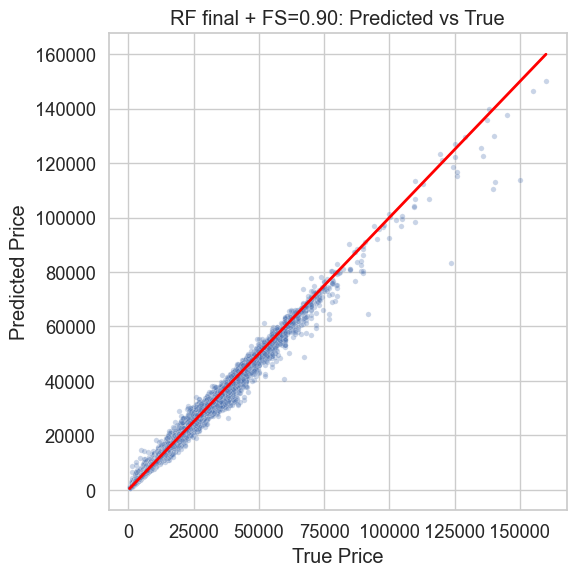

In [25]:

plot_pred_vs_true(rf_final, MODEL_NAME)


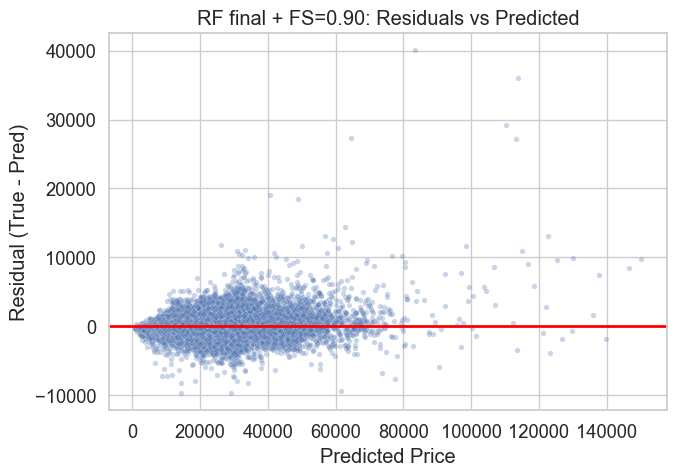

In [26]:
plot_residuals(rf_final, MODEL_NAME)


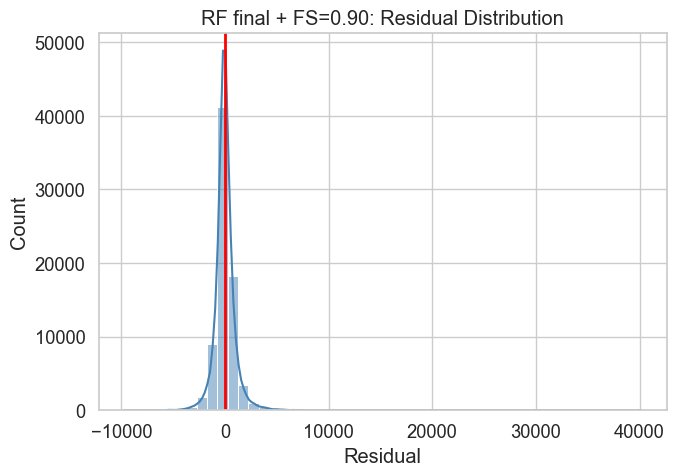

In [27]:
plot_residual_distribution(rf_final, MODEL_NAME)


Exception ignored in: <function ResourceTracker.__del__ at 0x106ec9e40>
Traceback (most recent call last):
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102fd1e40>
Traceback (most recent call last):
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 1

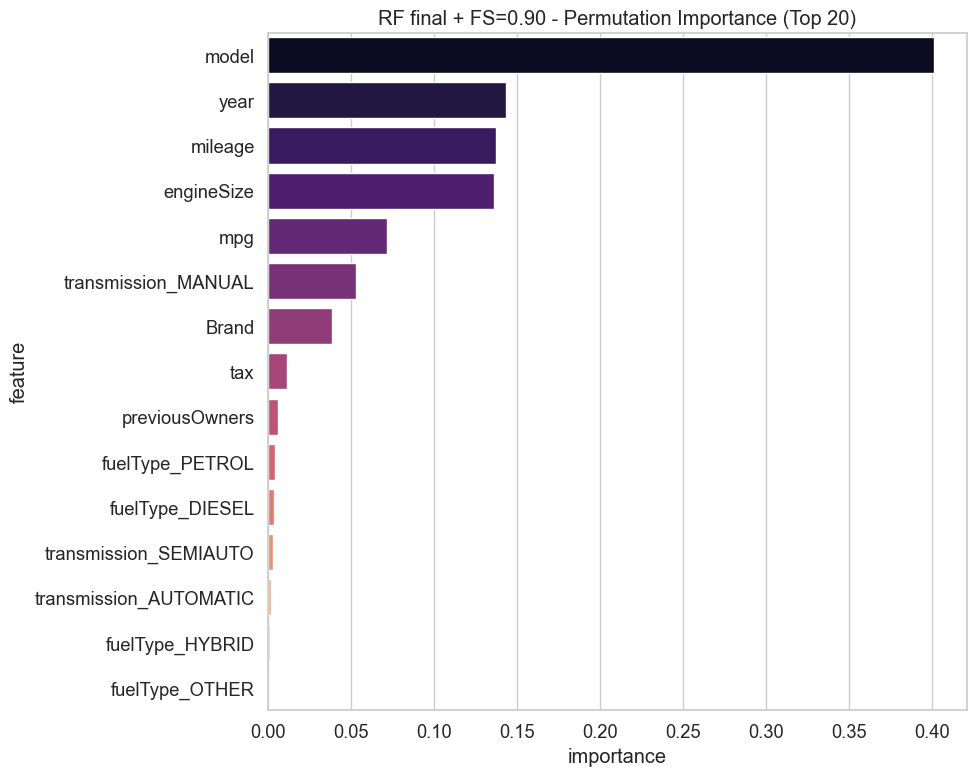

In [28]:
plot_permutation_importance(rf_final, MODEL_NAME, n_repeats=5, top=20)


Exception ignored in: <function ResourceTracker.__del__ at 0x104b71e40>
Traceback (most recent call last):
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1029a9e40>
Traceback (most recent call last):
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/franciscafernandes/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 1


SHAP for RF final + FS=0.90 (sample size = 2000)


/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_50251/2697768544.py:32: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)


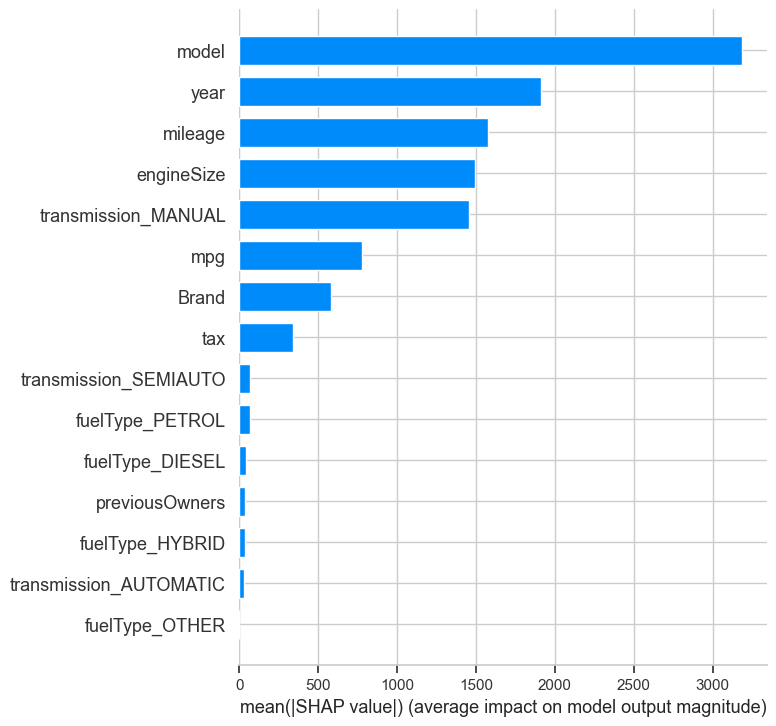

/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_50251/2697768544.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=True)


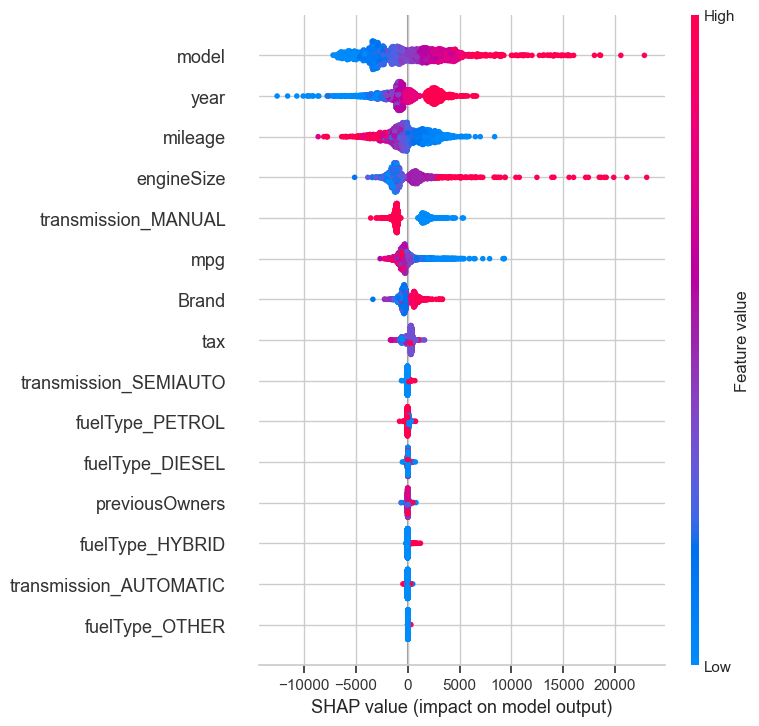

In [29]:
apply_shap(rf_final, X_full_sel, model_name=MODEL_NAME, sample_size=2000)

/var/folders/bd/t15rp69d53n0dgbv492qs36h0000gn/T/ipykernel_50251/1042059889.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=imp_df, palette="viridis")


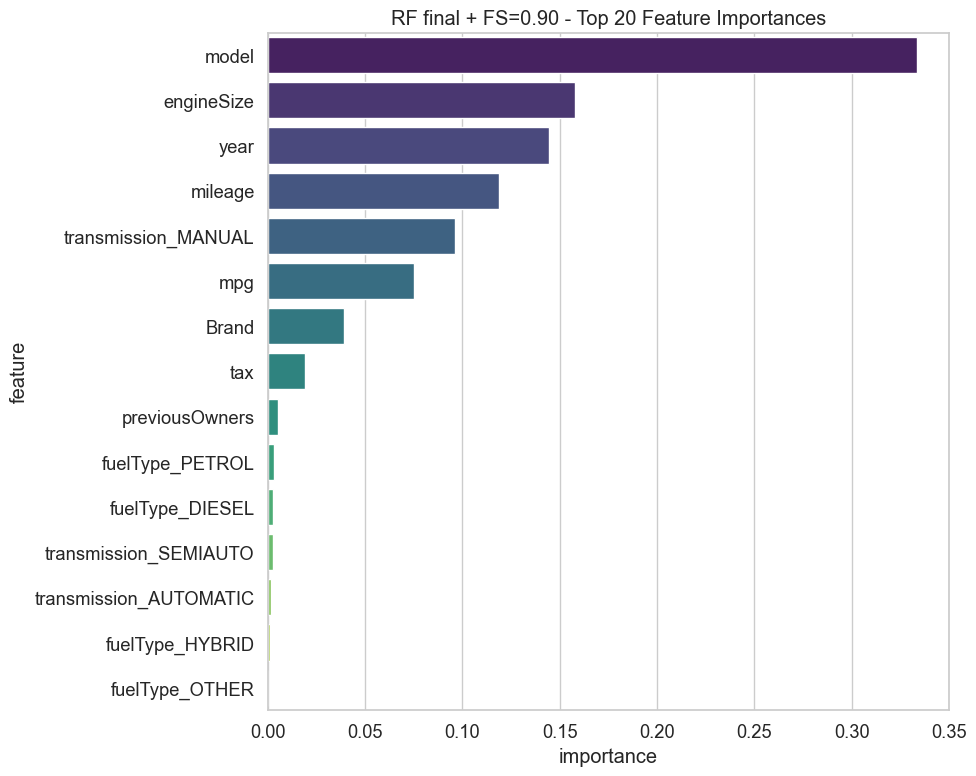

In [30]:

plot_feature_importance(rf_final, MODEL_NAME, top=20)



In [31]:
freq_df = compute_split_frequency(rf_final)
display(freq_df.head(20))



,feature,split_count
3,mileage,2053288
7,previousOwners,955958
8,mpg,774312
2,model,423123
5,tax,408658
4,year,249984
1,Brand,238327
0,engineSize,236687
6,transmission_AUTOMATIC,104501
10,transmission_SEMIAUTO,101882


In [32]:
# Restore original variable (optional, but cleaner)
X_full_final = X_full_final_backup

In [20]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
N_SPLITS = 8
RANDOM_STATE = 42
FS_KEEP_RATIO = 0.90  # keep 90% most important features (RF importance)

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ---------------------------------------------------------
# FIXED CONFIG (your request)
# ---------------------------------------------------------
params = {
    "n_estimators": 200,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": 0.5,
    "max_depth": 20,
    "bootstrap": True,
}

# ---------------------------------------------------------
# IMPORTANT:
# assumes these exist in your notebook (same as your original cell):
# X, y
# numeric_features, categorical_features
# valid_brands, valid_models_by_brand, valid_transmissions, valid_fueltypes
# fit_* and transform_* helpers
# MyTargetEncoder, MyOneHotEncoder
# ---------------------------------------------------------

log_path = "rf_fixed_cv_fs90_config_200depth20.txt"

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# RandomForest - Fixed Config CV (NO log-target) + FS=0.90")
    log(f"N_SPLITS = {N_SPLITS}")
    log(f"params = {params}")
    log(f"FS_KEEP_RATIO = {FS_KEEP_RATIO}")

    # fold metrics (VAL)
    fold_rmses, fold_maes, fold_r2s = [], [], []

    # fold metrics (TRAIN)
    fold_rmses_train, fold_maes_train, fold_r2s_train = [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

        log("")
        log(f"[FIXED|F{fold}] -- FOLD {fold}/{N_SPLITS}")

        # split the data into train and validation for the current fold
        X_train = X.iloc[train_idx].copy()
        X_val   = X.iloc[val_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_val   = y.iloc[val_idx].copy()

        log(f"[FIXED|F{fold}] X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
        log(f"[FIXED|F{fold}] y_train shape: {y_train.shape}, y_val shape: {y_val.shape}")

        # log missing values before imputations
        log(f"[FIXED|F{fold}] NaNs before (just numerical):")
        log(str(X_train[numeric_features].isna().sum()))
        log(f"[FIXED|F{fold}] NaNs before (categorical):")
        log(str(X_train[categorical_features].isna().sum()))

        unknown_counts_before = (X_train[categorical_features] == "UNKNOWN").sum()
        log(f"[FIXED|F{fold}] 'UNKNOWN' before (categorical):")
        log(str(unknown_counts_before))

        # ---------------------------------------------------------
        # PREPROCESSING (fit on train, transform on val)
        # ---------------------------------------------------------
        year_state = fit_year_median(X_train, year_col="year", model_col="model")
        X_train = transform_year_with_model_median(X_train, state=year_state)
        X_val   = transform_year_with_model_median(X_val,   state=year_state)

        mileage_state = fit_mileage_imputer(X_train, mileage_col="mileage", do_abs=True)
        X_train = transform_mileage_imputer(X_train, state=mileage_state)
        X_val   = transform_mileage_imputer(X_val,   state=mileage_state)

        engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
        X_train = transform_engine_size_imputer(X_train, state=engine_state)
        X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

        mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
        X_train = transform_mpg_imputer(X_train, state=mpg_state)
        X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

        owners_state = fit_previous_owners_imputer(
            X_train,
            owners_col="previousOwners",
            year_col="year",
            mileage_col="mileage"
        )
        X_train = transform_previous_owners_imputer(X_train, state=owners_state)
        X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

        brand_state = fit_ambiguous_brand_resolver(
            train_df=X_train,
            valid_brands=valid_brands,
            brand_col="Brand",
            model_col="model",
            year_col="year",
        )
        X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
        X_val,   _, _ = transform_ambiguous_brands(X_val,   brand_state)

        model_state = fit_invalid_model_resolver(
            train_df=X_train,
            valid_models_by_brand=valid_models_by_brand,
            brand_col="Brand",
            model_col="model",
            year_col="year",
            fuel_col="fuelType",
            mpg_col="mpg",
        )
        X_train, _, _ = transform_invalid_models(X_train, model_state)
        X_val,   _, _ = transform_invalid_models(X_val,   model_state)

        transm_state = fit_transmission_resolver(
            train_df=X_train,
            valid_transmissions=valid_transmissions,
            transm_col="transmission",
            brand_col="Brand",
            model_col="model",
            fuel_col="fuelType",
        )
        X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
        X_val,   _, _ = transform_transmission_resolver(X_val,   transm_state)

        fuel_state = fit_fueltype_resolver(
            train_df=X_train,
            valid_fueltypes=valid_fueltypes,
            fuel_col="fuelType",
            brand_col="Brand",
            model_col="model",
            transm_col="transmission",
        )
        X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
        X_val,   _, _ = transform_fueltype_resolver(X_val,   fuel_state)

        log(f"[FIXED|F{fold}] Após resolver fuelType:")
        log("  Valores distintos (train): " +
            str(sorted(X_train["fuelType"].astype(str).str.upper().unique())))

        X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
        X_val   = transform_tax_custom_rules(X_val,   "tax", "year", "fuelType", "engineSize")

        # ---------------------------------------------------------
        # ENCODING (TE for Brand+model, OHE for the rest)
        # ---------------------------------------------------------
        high_card_features = ["Brand", "model"]
        low_card_features  = [c for c in categorical_features if c not in high_card_features]

        te = MyTargetEncoder(smoothing=5)
        te.fit(X_train[high_card_features], y_train)  # NO log-target here (matches your original cell)

        X_train_high = te.transform(X_train[high_card_features])
        X_val_high   = te.transform(X_val[high_card_features])

        ohe = MyOneHotEncoder()
        ohe.fit(X_train[low_card_features])

        X_train_low = ohe.transform(X_train[low_card_features])
        X_val_low   = ohe.transform(X_val[low_card_features])

        X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
        X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

        # ---------------------------------------------------------
        # NUMERICAL SCALING
        # ---------------------------------------------------------
        scaler = StandardScaler()
        X_train_num = scaler.fit_transform(X_train[numeric_features])
        X_val_num   = scaler.transform(X_val[numeric_features])

        X_train_num_df = pd.DataFrame(
            X_train_num,
            index=X_train.index,
            columns=[f"num_{col}" for col in numeric_features]
        )
        X_val_num_df = pd.DataFrame(
            X_val_num,
            index=X_val.index,
            columns=[f"num_{col}" for col in numeric_features]
        )

        X_train_final = pd.concat([X_train_num_df, X_train_cat], axis=1)
        X_val_final   = pd.concat([X_val_num_df,   X_val_cat],   axis=1)

        # ---------------------------------------------------------
        # FEATURE SELECTION (RF + SelectFromModel) — keep 90%
        # ---------------------------------------------------------
        rf_fs = RandomForestRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            max_features="sqrt",
            bootstrap=True
        )
        rf_fs.fit(X_train_final, y_train)  # NO log-target here

        importances = rf_fs.feature_importances_
        n_feats = len(importances)

        k = max(1, int(np.ceil(FS_KEEP_RATIO * n_feats)))
        threshold = np.sort(importances)[-k]

        sfm = SelectFromModel(rf_fs, threshold=threshold, prefit=True)
        selected_cols = X_train_final.columns[sfm.get_support()]

        X_train_final = pd.DataFrame(
            sfm.transform(X_train_final),
            index=X_train_final.index,
            columns=selected_cols
        )
        X_val_final = pd.DataFrame(
            sfm.transform(X_val_final),
            index=X_val_final.index,
            columns=selected_cols
        )

        log(f"[FIXED|F{fold}] FS keep_ratio={FS_KEEP_RATIO:.2f}: kept {X_train_final.shape[1]}/{n_feats} features")

        # ---------------------------------------------------------
        # TRAIN MAIN MODEL (fixed params) + METRICS
        # ---------------------------------------------------------
        rf = RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params
        )

        log(f"[FIXED|F{fold}] training RandomForestRegressor...")
        rf.fit(X_train_final, y_train)

        y_pred_train = rf.predict(X_train_final)
        y_pred_val   = rf.predict(X_val_final)

        rmse_val = float(np.sqrt(mean_squared_error(y_val, y_pred_val)))
        mae_val  = float(mean_absolute_error(y_val, y_pred_val))
        r2_val   = float(r2_score(y_val, y_pred_val))

        rmse_tr = float(np.sqrt(mean_squared_error(y_train, y_pred_train)))
        mae_tr  = float(mean_absolute_error(y_train, y_pred_train))
        r2_tr   = float(r2_score(y_train, y_pred_train))

        log(f"[FIXED|F{fold}] TRAIN -> RMSE: {rmse_tr:.4f} | MAE: {mae_tr:.4f} | R²: {r2_tr:.4f}")
        log(f"[FIXED|F{fold}] VAL   -> RMSE: {rmse_val:.4f} | MAE: {mae_val:.4f} | R²: {r2_val:.4f}")

        fold_rmses.append(rmse_val)
        fold_maes.append(mae_val)
        fold_r2s.append(r2_val)

        fold_rmses_train.append(rmse_tr)
        fold_maes_train.append(mae_tr)
        fold_r2s_train.append(r2_tr)

    # ---------------------------------------------------------
    # SUMMARY
    # ---------------------------------------------------------
    mean_rmse_val = float(np.mean(fold_rmses))
    mean_mae_val  = float(np.mean(fold_maes))
    mean_r2_val   = float(np.mean(fold_r2s))

    mean_rmse_tr = float(np.mean(fold_rmses_train))
    mean_mae_tr  = float(np.mean(fold_maes_train))
    mean_r2_tr   = float(np.mean(fold_r2s_train))

    log("")
    log("# =============================")
    log("# CV SUMMARY (Fixed Config)")
    log("# =============================")
    log(f"TRAIN RMSE mean: {mean_rmse_tr:.4f} | MAE: {mean_mae_tr:.4f} | R²: {mean_r2_tr:.4f}")
    log(f"VAL   RMSE mean: {mean_rmse_val:.4f} | MAE: {mean_mae_val:.4f} | R²: {mean_r2_val:.4f}")
    log(f"Logs stored at: {log_path}")

print(f"\nLogs stored at: {log_path}")


# RandomForest - Fixed Config CV (NO log-target) + FS=0.90
N_SPLITS = 8
params = {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20, 'bootstrap': True}
FS_KEEP_RATIO = 0.9

[FIXED|F1] -- FOLD 1/8
[FIXED|F1] X_train shape: (66476, 10), X_val shape: (9497, 10)
[FIXED|F1] y_train shape: (66476,), y_val shape: (9497,)
[FIXED|F1] NaNs before (just numerical):
year              1306
mileage           1252
engineSize        1344
tax               6940
mpg               6961
previousOwners    1331
dtype: int64
[FIXED|F1] NaNs before (categorical):
Brand           0
model           0
transmission    0
fuelType        0
dtype: int64
[FIXED|F1] 'UNKNOWN' before (categorical):
Brand           1328
model           1314
transmission    1944
fuelType        1296
dtype: Int64
[FIXED|F1] Após resolver fuelType:
  Valores distintos (train): ['DIESEL', 'ELECTRIC', 'HYBRID', 'OTHER', 'PETROL']


/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[FIXED|F1] FS keep_ratio=0.90: kept 15/16 features
[FIXED|F1] training RandomForestRegressor...
[FIXED|F1] TRAIN -> RMSE: 1015.7392 | MAE: 642.7144 | R²: 0.9892
[FIXED|F1] VAL   -> RMSE: 1999.4559 | MAE: 1266.1232 | R²: 0.9558

[FIXED|F2] -- FOLD 2/8
[FIXED|F2] X_train shape: (66476, 10), X_val shape: (9497, 10)
[FIXED|F2] y_train shape: (66476,), y_val shape: (9497,)
[FIXED|F2] NaNs before (just numerical):
year              1312
mileage           1289
engineSize        1316
tax               6942
mpg               6941
previousOwners    1363
dtype: int64
[FIXED|F2] NaNs before (categorical):
Brand           0
model           0
transmission    0
fuelType        0
dtype: int64
[FIXED|F2] 'UNKNOWN' before (categorical):
Brand           1337
model           1330
transmission    1967
fuelType        1310
dtype: Int64
[FIXED|F2] Após resolver fuelType:
  Valores distintos (train): ['DIESEL', 'ELECTRIC', 'HYBRID', 'OTHER', 'PETROL']


/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[FIXED|F2] FS keep_ratio=0.90: kept 15/16 features
[FIXED|F2] training RandomForestRegressor...
[FIXED|F2] TRAIN -> RMSE: 1022.1550 | MAE: 642.0918 | R²: 0.9890
[FIXED|F2] VAL   -> RMSE: 2140.7635 | MAE: 1292.6790 | R²: 0.9512

[FIXED|F3] -- FOLD 3/8
[FIXED|F3] X_train shape: (66476, 10), X_val shape: (9497, 10)
[FIXED|F3] y_train shape: (66476,), y_val shape: (9497,)
[FIXED|F3] NaNs before (just numerical):
year              1297
mileage           1292
engineSize        1326
tax               6911
mpg               6935
previousOwners    1370
dtype: int64
[FIXED|F3] NaNs before (categorical):
Brand           0
model           0
transmission    0
fuelType        0
dtype: int64
[FIXED|F3] 'UNKNOWN' before (categorical):
Brand           1336
model           1334
transmission    1943
fuelType        1323
dtype: Int64
[FIXED|F3] Após resolver fuelType:
  Valores distintos (train): ['DIESEL', 'ELECTRIC', 'HYBRID', 'OTHER', 'PETROL']


...

[FIXED|F6] FS keep_ratio=0.90: kept 15/16 features
[FIXED|F6] training RandomForestRegressor...
[FIXED|F6] TRAIN -> RMSE: 1027.1363 | MAE: 642.3714 | R²: 0.9888
[FIXED|F6] VAL   -> RMSE: 2140.0948 | MAE: 1268.4682 | R²: 0.9525

[FIXED|F7] -- FOLD 7/8
[FIXED|F7] X_train shape: (66477, 10), X_val shape: (9496, 10)
[FIXED|F7] y_train shape: (66477,), y_val shape: (9496,)
[FIXED|F7] NaNs before (just numerical):
year              1311
mileage           1272
engineSize        1319
tax               6885
mpg               6903
previousOwners    1358
dtype: int64
[FIXED|F7] NaNs before (categorical):
Brand           0
model           0
transmission    0
fuelType        0
dtype: int64
[FIXED|F7] 'UNKNOWN' before (categorical):
Brand           1322
model           1302
transmission    1937
fuelType        1334
dtype: Int64
[FIXED|F7] Após resolver fuelType:
  Valores distintos (train): ['DIESEL', 'ELECTRIC', 'HYBRID', 'OTHER', 'PETROL']


/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[FIXED|F7] FS keep_ratio=0.90: kept 15/16 features
[FIXED|F7] training RandomForestRegressor...
[FIXED|F7] TRAIN -> RMSE: 1020.9277 | MAE: 645.2366 | R²: 0.9890
[FIXED|F7] VAL   -> RMSE: 2047.8034 | MAE: 1247.1966 | R²: 0.9557

[FIXED|F8] -- FOLD 8/8
[FIXED|F8] X_train shape: (66477, 10), X_val shape: (9496, 10)
[FIXED|F8] y_train shape: (66477,), y_val shape: (9496,)
[FIXED|F8] NaNs before (just numerical):
year              1314
mileage           1303
engineSize        1315
tax               6902
mpg               6919
previousOwners    1367
dtype: int64
[FIXED|F8] NaNs before (categorical):
Brand           0
model           0
transmission    0
fuelType        0
dtype: int64
[FIXED|F8] 'UNKNOWN' before (categorical):
Brand           1343
model           1339
transmission    1948
fuelType        1318
dtype: Int64
[FIXED|F8] Após resolver fuelType:
  Valores distintos (train): ['DIESEL', 'ELECTRIC', 'HYBRID', 'OTHER', 'PETROL']


/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/Users/franciscafernandes/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


[FIXED|F8] FS keep_ratio=0.90: kept 15/16 features
[FIXED|F8] training RandomForestRegressor...
[FIXED|F8] TRAIN -> RMSE: 1022.1751 | MAE: 643.1325 | R²: 0.9891
[FIXED|F8] VAL   -> RMSE: 2053.9976 | MAE: 1251.0509 | R²: 0.9532

# =============================
# CV SUMMARY (Fixed Config)
# =============================
TRAIN RMSE mean: 1019.4830 | MAE: 642.0033 | R²: 0.9890
VAL   RMSE mean: 2174.9816 | MAE: 1275.8669 | R²: 0.9499
Logs stored at: rf_fixed_cv_fs90_config_200depth20.txt

Logs stored at: rf_fixed_cv_fs90_config_200depth20.txt


## 4. Conclusions

### 4.1. Results obtained and overall performance discussion

| Type of Experiment                              | FS ratio | RMSE (val)    | RMSE (train)  | MAE (val)    | MAE (train) | Amount of Features | Best config |
|---                                              |---:     |---:           |---:           |---:          |---:         |---:                |---|
| Original Features (no FS / no FE)               | —       | 2262.761510   | 1560.356118   | 1336.104531  | 999.831279  | —                  | {'n_estimators': 1000, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15, 'bootstrap': True} |
| No previousOwners; target log (no FE / no FS)   | —       | 2376.031570   | 1749.613634   | 1306.843493  | 966.927495  | —                  | {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True} |
| All features + engineered (no FS, log)          | —       | 2346.4786376  | 1714.723680   | 1311.981162  | 922.295405  | —                  | {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20, 'bootstrap': True} |
| All features + engineered (FS(65%), log)          | 0.65       | 2360.277  | 1638.582516  | 1316.771776  | 905.519631  | 17                  | {'n_estimators': 1000, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'bootstrap': True, 'fs_keep_ratio': 0.65}|
| Original Features no prevown + age + log   no fs      | -       | 2374.4046  | 1749.480161  | 1306.25473  | 966.646366  | -                  | {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True}|
| Original Features no prevown + age + log   fs(80)      | 0.8       | 2382.924698  | 1762.412816  | 1310.153686  | 972.000631 | 12                  | {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.33, 'max_depth': 20, 'bootstrap': True}|

*Table 1 – Best configuration and main metrics for each experiment*

<div style="text-align: justify; max-width: 1300px; margin: 1 auto;">

- Our best obtained RMSE was approximately 2262.76 for the setting with no feature ablation, no feature engineering and no feature selection, with a validation MAE score of 1336.10.
- Even for the experiments in which `bootstrap=False` was included in the hyperparameter search space, the best configuration found still had this value set to True, which is consistent with the thesis that bagging helps the model generalize better.
- Feature engineering and applying a logarithmic transformation to the target (price) did not improve RMSE, and applying feature selection did not improve it either.
- Although some configurations present a slightly better MAE, they did not improve RMSE (and in some cases even increased it). This suggests that the model reduced the average error magnitude, but did not reduce (and may have increased) a small number of large errors, which heavily influence RMSE due to its quadratic penalty.
- Across all experiment settings, the training error is consistently lower than the validation error (e.g., RMSE(train) ranges between 1560–1762 versus RMSE(val) between 2263–2383). This persistent gap (roughly 620–720) indicates that the Random Forest still shows residual variance and some overfitting: it fits the training data much better than it performs on unseen validation data, even with bagging enabled. Compared to a single decision tree, a larger gap is typically expected, so although Random Forest reduces overfitting, it does not eliminate it entirely.
- In order to obtain these results, we conducted a random search for each setting, which we recognise was not the most methodologically rigorous way to conduct the comparisons. In addition, in the beginning we were only experimenting with the `max_features` parameter set to None and allowing `bootstrap` to be either True or False. However, as we gained more experience, researched more about the topic and analysed the results, we concluded that setting `bootstrap=True` was the most appropriate approach and that it also made sense to diversify the range of options tested for max_features. That said, in a highly rigorous experimental setting, changing the search space and strategy over time could lead to an unfair comparison across configurations.

</div>

### 4.2. Visualizing the model performance and feature importance

<div style="text-align: justify; max-width: 1300px; margin: 1 auto;">

- In order to compare all models in a more “fair” way, we used the best hyperparameter configuration obtained in the random search, under a consistent setting: no feature ablation, no feature engineering and no feature selection. This choice is also motivated by the fact that this baseline was the best-performing scenario for the stacking model.
- We included the following visualizations: __Predicted vs. True Values plot__, __Residuals vs. Predicted Values plot__, __Residual Distribution plot__, __Permutation Importance plot__, __Model-based Feature Importance plot__, __SHAP Summary Bar plot and SHAP Beeswarm plot and we computed the Split Frequency per Feature__.    
</div>     